# Trabajo individual: Clasificación
___
- Universidad Carlos III de Madrid, 4º Curso
- Asignatura: Métodos estadísticos en minería de datos
- Autor: Miriam Gómez Arias
___

# Introduccón

El conjunto de datos seleccionado procede del repositorio **Student Performance Prediction**, que recopila información detallada sobre estudiantes de educación secundaria en Portugal. Se trata de un dataset especialmente rico, pues combina variables socioeconómicas, familiares, académicas y de comportamiento, lo que permite estudiar el rendimiento estudiantil desde una perspectiva multidimensional.

Para adaptarlo a un problema de clasificación se emplean las calificaciones de la asignatura de portugués (G1, G2 y G3). La variable objetivo se construye calculando la media de estas tres evaluaciones de cada trimestre para obtener una nota numerica final la cual se transformará posteriormente en una categoría siguiendo la escala oficial portuguesa:

- 0–9.9: Suspenso  
- 10–13.9: Suficiente  
- 14–16.9: Bien 
- 17–18.9: Muy bien
- 19–20: Excelente  

Esta transformación convierte el problema en una tarea de clasificación con claro interés educativo y social. El análisis permite identificar perfiles de riesgo, comprender qué factores están asociados a distintos niveles de rendimiento y plantear estrategias de intervención o apoyo personalizado basadas en evidencia.

El dataset contiene más de 600 observaciones y más de 30 variables, entre ellas tiempo de estudio, consumo de alcohol, nivel educativo de los padres, calidad de relaciones familiares, número de faltas, apoyo escolar adicional, situación económica y motivación del estudiante. Esta diversidad lo convierte en un candidato adecuado para aplicar múltiples técnicas vistas en la asignatura.

Algunas de las tecnicas que se aplicaran a lo largo del trabajo son:

- Análisis exploratorio y visualización, para identificar patrones y relaciones entre factores sociales, familiares y académicos.  
- Reducción de la dimensionalidad (PCA), con el objetivo de detectar estructuras latentes que agrupen hábitos y comportamientos estudiantiles.  
- Clustering, destinado a descubrir perfiles de estudiantes sin utilizar directamente la nota final.  
- Modelos supervisados como árboles de decisión y redes neuronales, enfocados en predecir la categoría final del estudiante.  
- Comparación entre interpretabilidad y rendimiento, analizando ventajas y limitaciones de modelos explicables frente a modelos más complejos.

En cuanto a las hipótesis del estudio:

- El tiempo de estudio y el número de faltas serán los factores más influyentes en la categoría final, al tratarse de indicadores académicos directos.  
- Las variables socioemocionales y familiares influirán en el rendimiento, aunque de manera secundaria respecto a las académicas.  
- El clustering revelará grupos con perfiles característicos, como estudiantes de alto riesgo, estudiantes motivados con baja dedicación y estudiantes con alta constancia.  
- Las redes neuronales alcanzarán mayor precisión que los árboles de decisión, aunque con menor interpretabilidad, lo que permitirá reflexionar sobre su utilidad en contextos educativos reales.

Este dataset resulta especialmente adecuado para el trabajo por varias razones:

- Permite analizar un fenómeno complejo y socialmente relevante.  
- Facilita aplicar técnicas supervisadas y no supervisadas de forma integrada.  
- Proporciona una variable objetivo construida de manera razonada y justificable.  
- Exige interpretar los resultados en su contexto real, alineándose con las competencias de la asignatura.  
- Permite comparar modelos evaluando sus ventajas y limitaciones.

En conjunto, este dataset ofrece un marco sólido para desarrollar todas las etapas del proceso de minería de datos y obtener conclusiones fundamentadas sobre los factores asociados al rendimiento educativo un tema muy interesante y que puede ayudar a muchos jóvenes.

Leyenda de las variables con las que trabajaremos a lo largo del trabajo:

- school: Escuela del estudiante (GP = Gabriel Pereira, MS = Mousinho da Silveira).

- sex: Sexo del estudiante (F = femenino, M = masculino).

- age: Edad del estudiante (15–22 años).

- address: Tipo de residencia (U = urbano, R = rural).

- famsize: Tamaño familiar (LE3 = ≤ 3 miembros, GT3 = > 3 miembros).

- Pstatus: Convivencia de los padres (T = juntos, A = separados).

- Medu: Nivel educativo de la madre (0–4; 0 = ninguno, 4 = educación superior).

- Fedu: Nivel educativo del padre (0–4; igual escala que Medu).

- Mjob: Profesión de la madre (teacher, health, services, at_home, other).

- Fjob: Profesión del padre (mismas categorías que Mjob).

- guardian: Tutor principal del estudiante (mother, father, other).

- reason: Razón para elegir la escuela (home, reputation, course, other).

- traveltime: Tiempo de viaje al colegio (1 = <15 min, 4 = >1 h).

- studytime: Tiempo de estudio semanal (1 = <2 h, 4 = >10 h).

- failures: número de fracasos de clase anteriores (0–3; 4 = tres o más).

- schoolsup: Apoyo educativo extra (yes, no).

- famsup: Apoyo educativo familiar (yes, no).

- paid: Clases de pago relacionadas con la asignatura (yes, no).

- activities: Actividades extraescolares (yes, no).

- nursery: Asistencia a guardería (yes, no).

- higher: Deseo de cursar estudios superiores (yes, no).

- internet: Acceso a Internet en casa (yes, no).

- romantic: Relación romántica (yes, no).

- famrel: Calidad de relaciones familiares (1 = muy mala, 5 = excelente).

- freetime: Tiempo libre tras la escuela (1 = muy bajo, 5 = muy alto).

- goout: Frecuencia de salir con amigos (1 = muy baja, 5 = muy alta).

- Dalc: Consumo de alcohol entre semana (1 = muy bajo, 5 = muy alto).

- Walc: Consumo de alcohol en fines de semana (1 = muy bajo, 5 = muy alto).

- health: Estado de salud actual (1 = muy malo, 5 = muy bueno).

- absences: Número de ausencias escolares (0–93).

- G1: Nota del primer periodo (0–20).

- G2: Nota del segundo periodo (0–20).

- G3: Nota del tercer periodo (0-20).

# 2. Manipulación y visualización de datos

## 2.1 Carga y exploración inicial del dataset

En esta primera fase del trabajo se llevó a cabo la carga del dataset correspondiente al rendimiento académico de estudiantes de secundaria en Portugal. Para ello, se utilizó la librería pandas, una herramienta fundamental en el análisis de datos en Python.

In [1]:
import pandas as pd
ruta = r"C:\Users\miria\OneDrive\Escritorio\trabajo\student-por.csv"
df = pd.read_csv(ruta, sep=";", quotechar='"')
print(df.head())
print(df.shape)
print(df.info(), "\n")
num_duplicados = df.duplicated().sum()
print( num_duplicados)

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  13  12  
3      3        2      2     1     1      5        0  14  14  14  
4      4        3      2     1     2      5        0  11  13  13  

[5 rows x 33 columns]
(649, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data c

La carga inicial del dataset se realizó mediante `pd.read_csv()`, especificando `sep=";"` debido a que el archivo original utiliza punto y coma como separador y `quotechar='"'` para manejar correctamente aquellas columnas cuyos valores aparecen entrecomillados. El proceso se completó sin errores y generó un DataFrame denominado `df`. Una primera visualización mediante `df.head()` permitió observar las cinco primeras filas. En esta inspección inicial se identificaron columnas como `school`, `sex`, `age`, `address`, `famsize`, `Medu`, `Fedu`, `studytime`, `failures`, `absences` y las tres calificaciones `G1`, `G2` y `G3`. No se detectaron valores vacíos en estas primeras observaciones, lo que sugiere una estructura consistente y bien definida. También se evidenció la heterogeneidad del conjunto de datos, ya que combina variables categóricas (como `school`, `sex` o `address`) con variables numéricas (`age`, `studytime`, `failures`), lo cual anticipa la necesidad de un preprocesamiento adecuado antes de aplicar técnicas de modelado.

Al consultar las dimensiones mediante `df.shape`, el resultado fue `(649, 33)`, indicando que el dataset contiene 649 estudiantes y 33 variables asociadas a cada uno de ellos. Este volumen de datos resulta apropiado para el análisis exploratorio, la generación de modelos supervisados y la aplicación de técnicas de clasificación. Finalmente, el examen de los tipos de datos proporcionado por `df.dtypes` mostró la coexistencia de aproximadamente 22 variables categóricas (epresentadas como `object`) y 11 variables numéricas (principalmente de tipo `int64`), entre ellas las notas académicas que se utilizarán para construir la variable objetivo del estudio. Además, nuestro conjunto de datos no cuenta con valores duplicados lo cuás es perfecto para llevar a cabo nuestro análisis.


## 2.2 Manipulación y limpieza

In [2]:
df["G_media"] = df[["G1", "G2", "G3"]].mean(axis=1)
def clasificar_media(x):
    if x < 10:
        return "Suspenso"
    elif x < 14:
        return "Suficiente"
    elif x < 17:
        return "Bien"
    elif x < 19:
        return "Muy bien"
    else:
        return "Excelente"

df["categoria_nota"] = df["G_media"].apply(clasificar_media)
df["categoria_nota"] = df["categoria_nota"].astype("category")

Para este trabajo se generó una nueva variable que resume el rendimiento académico de cada estudiante. Primero, se calculó la media de las tres calificaciones disponibles en el dataset (G1, G2 y G3), lo que permite obtener una medida más estable y representativa que cualquiera de las notas individuales. Esta media se almacenó en una nueva columna denominada `G_media`.

A continuación, se transformó esta media numérica en una variable categórica utilizando la escala oficial portuguesa de calificaciones. Para ello, se definió una función que asigna una etiqueta cualitativa (Suspenso, Suficiente, Bien, Muy bien o Excelente) en función del rango en el que se encuentre la media obtenida. Posteriormente, esta categoría se incorporó al DataFrame como una nueva columna `categoria_nota` y se declaró formalmente como tipo categórico.

El resultado es una variable objetivo perfectamente adaptada al problema de clasificación planteado: convierte un valor numérico continuo en categorías interpretables y coherentes con el sistema educativo portugués. Esta transformación facilita tanto el análisis exploratorio como la aplicación de modelos supervisados, al tiempo que permite interpretar mejor los perfiles de rendimiento académico dentro del conjunto de datos.

In [3]:
print(df.isna().sum())

school            0
sex               0
age               0
address           0
famsize           0
Pstatus           0
Medu              0
Fedu              0
Mjob              0
Fjob              0
reason            0
guardian          0
traveltime        0
studytime         0
failures          0
schoolsup         0
famsup            0
paid              0
activities        0
nursery           0
higher            0
internet          0
romantic          0
famrel            0
freetime          0
goout             0
Dalc              0
Walc              0
health            0
absences          0
G1                0
G2                0
G3                0
G_media           0
categoria_nota    0
dtype: int64


Para evaluar la calidad de los datos y determinar si era necesario aplicar técnicas de imputación o limpieza, se analizó la presencia de valores nulos mediante el comando df.isna().sum(). Este método devuelve el número de valores faltantes en cada columna del DataFrame.

El resultado obtenido muestra que todas las variables del dataset contienen exactamente 0 valores nulos, incluyendo tanto las variables originales como las nuevas columnas creadas durante la manipulación de datos. Esto significa que el conjunto de datos está completamente completo y no presenta registros con información ausente.

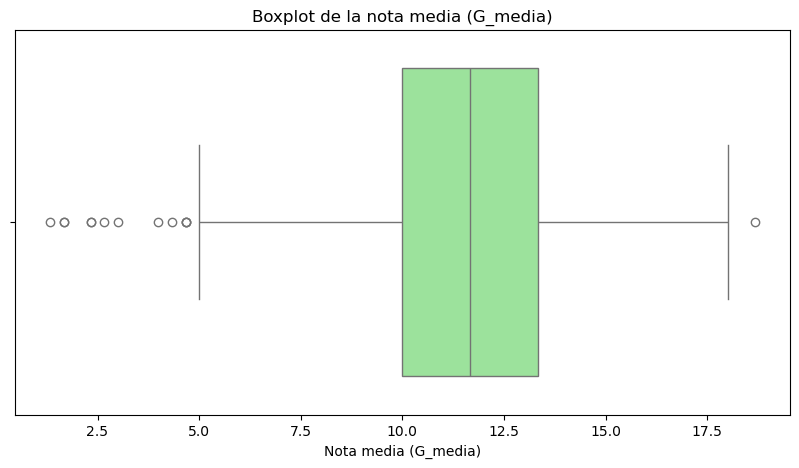

ANÁLISIS DE OUTLIERS EN G_media
Límite inferior: 5.00
Límite superior: 18.33
Número de outliers: 13
Porcentaje de outliers: 2.00%


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))
sns.boxplot(x=df["G_media"], color="lightgreen")
plt.title("Boxplot de la nota media (G_media)")
plt.xlabel("Nota media (G_media)")
plt.show()

Q1 = df["G_media"].quantile(0.25)
Q3 = df["G_media"].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers = df[(df["G_media"] < lim_inf) | (df["G_media"] > lim_sup)]

print("ANÁLISIS DE OUTLIERS EN G_media")
print(f"Límite inferior: {lim_inf:.2f}")
print(f"Límite superior: {lim_sup:.2f}")
print(f"Número de outliers: {outliers.shape[0]}")
print(f"Porcentaje de outliers: {outliers.shape[0] / df.shape[0] * 100:.2f}%")

En el análisis del dataset de estudiantes portugueses, se ha llevado a cabo una detección inicial de valores atípicos (outliers) empleando técnicas gráficas boxplot sobre la nota media (G_media). 

En este estudio se ha decidido no eliminar los valores atípicos del dataset, ya que representan comportamientos reales del entorno educativo y no errores de medición. Además de que solo hay un 2% de outliers. Estos casos extremos (como por ejemplo podrian ser estudiantes con muchas ausencias, rendimientos muy bajos o muy altos, o consumos de alcohol elevados) aportan información valiosa sobre situaciones auténticas que afectan al rendimiento académico. Suprimirlos implicaría perder la capacidad de identificar perfiles de riesgo, analizar diferencias entre estudiantes extremos y promedio, y comprender patrones relevantes como el absentismo o el fracaso escolar. Además, eliminar outliers podría distorsionar la realidad del fenómeno estudiado, generando modelos menos representativos y menos útiles para escenarios reales. Desde una perspectiva analítica y educativa, los valores atípicos enriquecen el estudio al permitir detectar clusters específicos, examinar factores influyentes en casos límite y obtener conclusiones más profundas. Por todo ello, mantener los outliers permite construir modelos más robustos y comprender mejor la variabilidad natural del alumnado.

## 2.3 Visualización

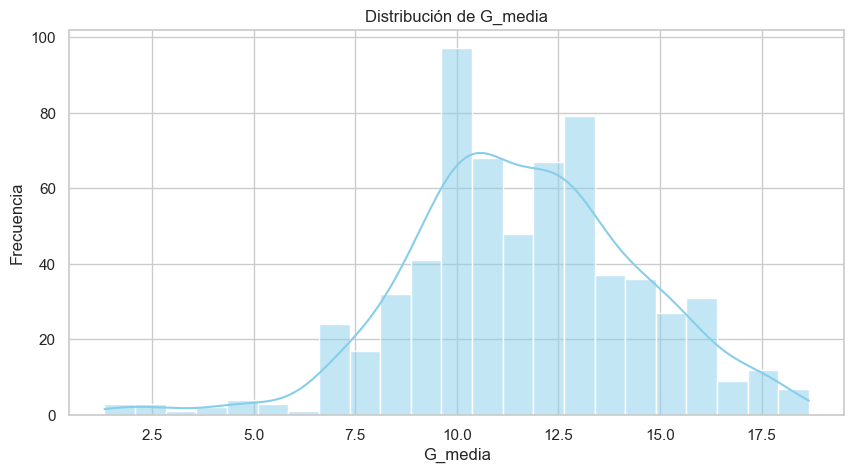

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(10,5))
sns.histplot(df["G_media"], kde=True, color="skyblue")
plt.title("Distribución de G_media")
plt.xlabel("G_media")
plt.ylabel("Frecuencia")
plt.show()


La variable G_media presenta una distribución aproximadamente normal, con ligera asimetría hacia la derecha. La mayoría de los estudiantes se sitúan entre 9 y 14 puntos, mientras que los valores muy bajos o muy altos son poco frecuentes pero representan casos reales de bajo o alto rendimiento académico. 

En cuanto a la normalización, no se considera necesaria para este estudio de momento y solo se aplicara una estandarizacion cuando sea necesario. Mantener la escala original (0–20) es útil para interpretar los resultados en un contexto educativo real. Además, muchos modelos como árboles de decisión, Random Forest o regresiones simples no requieren normalización. Solo sería conveniente normalizar si se aplicaran algoritmos sensibles a la escala, como KNN, SVM o redes neuronales.

En conclusión, G_media se conserva sin transformar: su distribución es correcta, sus valores extremos aportan información relevante y mantener su escala facilita la interpretación de los resultados.

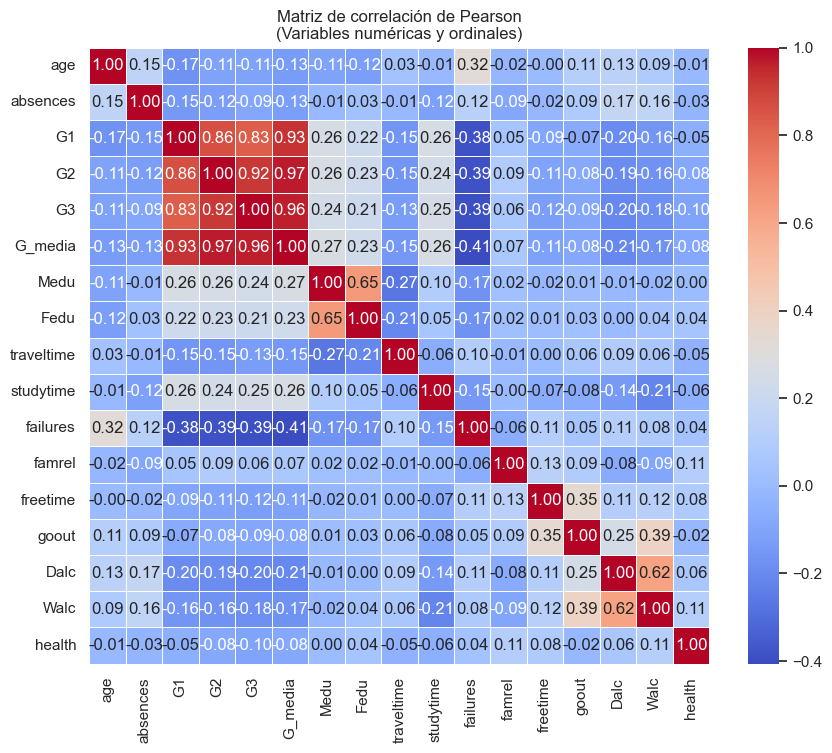

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

vars_pearson = [
    # Numéricas
    "age", "absences", "G1", "G2", "G3", "G_media",
    
    # Ordinales tratadas como numéricas
    "Medu", "Fedu", "traveltime", "studytime", "failures",
    "famrel", "freetime", "goout", "Dalc", "Walc", "health"
]

df_pearson = df[vars_pearson].copy()

corr_num = df_pearson.corr(method="pearson")

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_num,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación de Pearson\n(Variables numéricas y ordinales)")
plt.show()


La correlación de Pearson se ha utilizado para analizar la relación lineal entre variables cuantitativas, ya sean numéricas puras (como age y absences) o ordinales tratadas como numéricas (por ejemplo, Medu, Fedu, studytime, failures, famrel, Dalc, Walc, etc.). Este coeficiente mide tanto la intensidad como la dirección de la relación lineal entre dos variables en escala de intervalo o razón, por lo que resulta adecuado cuando existe un orden natural y una interpretación cuantitativa de las diferencias entre valores. En nuestro estudio, estas variables representan características académicas, familiares y de comportamiento que pueden aumentar o disminuir de forma gradual y, por tanto, es razonable analizarlas mediante Pearson para evaluar cómo se asocian entre sí y, especialmente, cómo se relacionan con la variable objetivo (G_media), en línea con el objetivo de identificar factores que influyen en el rendimiento académico.

Del correlograma se observa que la variable objetivo G_media presenta una correlación muy alta y positiva con las calificaciones individuales G1 (0.93), G2 (0.97) y G3 (0.96), lo cual es esperado ya que G_media es el promedio de estas. Además, G_media muestra una correlación moderada y positiva con las variables de nivel educativo de los padres (Medu y Fedu, alrededor de 0.27 y 0.23, respectivamente), y también con failures (0.41), indicando que un mayor número de fallos en clases anteriores se asocia con un promedio más bajo. Por otro lado, variables como age, absences, Dalc y Walc tienen correlaciones positivas débiles con G_media (entre 0.13 y 0.17), mientras que health presenta una correlación negativa débil (-0.08). Variables como famrel y freetime prácticamente no muestran relación lineal con G_media. En resumen, las calificaciones previas (G1, G2, G3) y los fallos (failures) son los predictores lineales más fuertes del promedio académico (G_media) en este conjunto de datos.

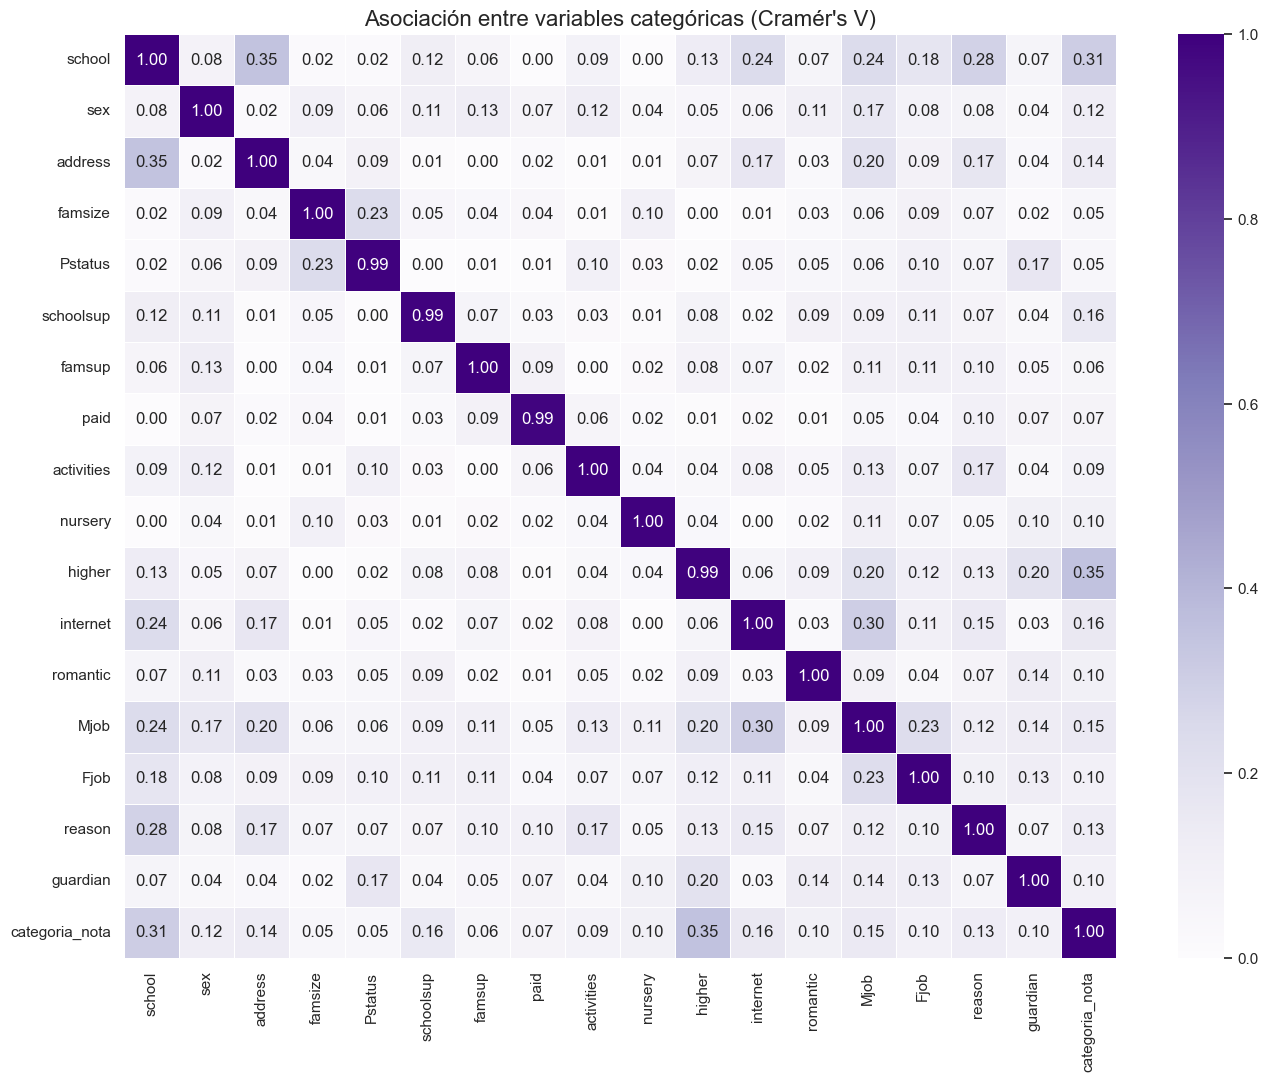

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()
    r, k = tabla.shape
    return np.sqrt((chi2 / n) / (min(r - 1, k - 1)))

vars_categoricas = [
    # Binarias
    "school", "sex", "address", "famsize", "Pstatus",
    "schoolsup", "famsup", "paid", "activities",
    "nursery", "higher", "internet", "romantic",

    # Nominales
    "Mjob", "Fjob", "reason", "guardian",

    # Variable objetivo
    "categoria_nota"
]

df_cat = df[vars_categoricas].copy()

for col in df_cat.columns:
    df_cat[col] = df_cat[col].astype("category")

cramer = pd.DataFrame(index=df_cat.columns, columns=df_cat.columns)

for c1 in df_cat.columns:
    for c2 in df_cat.columns:
        cramer.loc[c1, c2] = cramers_v(df_cat[c1], df_cat[c2])

cramer = cramer.astype(float)

plt.figure(figsize=(16,12))
sns.heatmap(
    cramer,
    cmap="Purples",
    annot=True,
    fmt=".2f",
    linewidths=.5
)

plt.title("Asociación entre variables categóricas (Cramér's V)", fontsize=16)
plt.show()


Por su parte, Cramér’s V se ha aplicado al análisis de variables categóricas nominales y binarias, como school, sex, address, famsize, Pstatus, Mjob, Fjob, reason, guardian, schoolsup, famsup, paid, activities, nursery, higher, internet y romantic, así como a su asociación con la variable objetivo categórica (categoria_nota). Este estadístico, derivado de la prueba ji-cuadrado, permite cuantificar la fuerza de asociación entre variables cualitativas sin asumir orden ni relación lineal, lo cual es fundamental en este caso, ya que estas variables representan categorías sin jerarquía inherente. Su uso es especialmente adecuado para explorar patrones estructurales y dependencias entre características sociofamiliares y educativas, y para evaluar hasta qué punto determinadas condiciones categóricas están asociadas con distintos niveles de rendimiento académico, cumpliendo así el objetivo exploratorio del estudio.

Analizando la matriz de asociación (Cramér's V) con la variable objetivo "categoria_nota", se observa que las variables con mayor asociación son "higher" (0.35), "school" (0.31) y "reason" (0.28). Esto sugiere que la aspiración de cursar educación superior, el centro educativo y la razón para elegirlo presentan una asociación moderada y relevante con la categoría de la nota final. Le siguen en importancia "Mjob" (0.24), "internet" (0.24) e "Fjob" (0.18), indicando que la ocupación de los padres y el acceso a internet en casa también tienen cierta relación con el rendimiento categorizado. Por otro lado, variables como "famsize", "Pstatus", "nursery" o "romantic" muestran asociaciones muy débiles (por debajo de 0.10) con la categoría de nota, lo que implica que, en este contexto, tienen poca influencia discernible. En resumen, los factores institucionales (school), de aspiraciones educativas (higher) y sociofamiliares (reason, Mjob, internet) son los que presentan una asociación más notable con la variable categórica de rendimiento académico.

C:\Users\miria\AppData\Local\Temp\ipykernel_12068\213873460.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="school", y="G_media", palette="pastel")


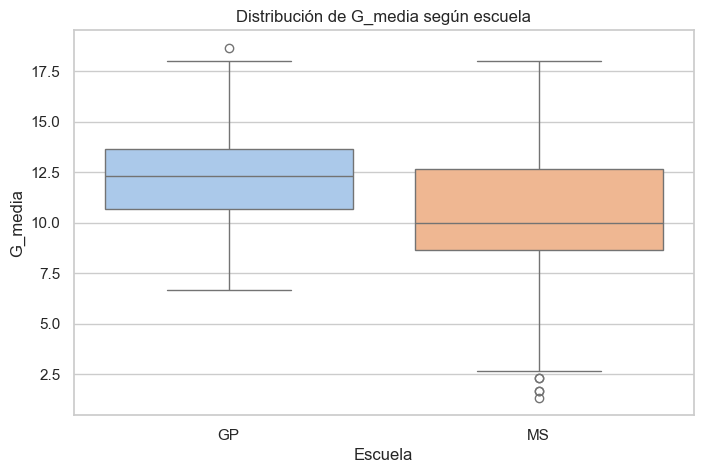

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="school", y="G_media", palette="pastel")
plt.title("Distribución de G_media según escuela")
plt.xlabel("Escuela")
plt.ylabel("G_media")
plt.show()

El gráfico compara la distribución de la nota media (G_media) entre los estudiantes de las dos escuelas del dataset: **GP (Gabriel Pereira)** y **MS (Mousinho da Silveira)**. A partir del boxplot se observan varios aspectos relevantes. La mediana de G_media es ligeramente superior en **GP**, ubicándose en torno a 12–13 puntos, mientras que en **MS** la mediana se sitúa cerca de los 10 puntos, lo que indica que los estudiantes de GP tienden a obtener mejores resultados promedio que los de MS. El rango intercuartílico es mayor en MS, lo que señala una mayor variabilidad de desempeño y una mezcla más amplia de resultados académicos. Además, en MS se detectan outliers muy bajos (entre 1 y 3 puntos), sugiriendo la presencia de rendimientos extremadamente bajos, algo menos pronunciado en GP. A pesar de estas diferencias, ambas escuelas muestran valores máximos de notas similares, alrededor de 18–19 puntos, lo que indica que en los dos centros hay estudiantes con alto rendimiento académico. En conjunto, estos patrones sugieren que GP presenta un rendimiento más estable y elevado en promedio, mientras que MS muestra mayor dispersión y heterogeneidad en las notas de los estudiantes.


C:\Users\miria\AppData\Local\Temp\ipykernel_12068\3634870170.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="studytime", y="G_media", palette="pastel")


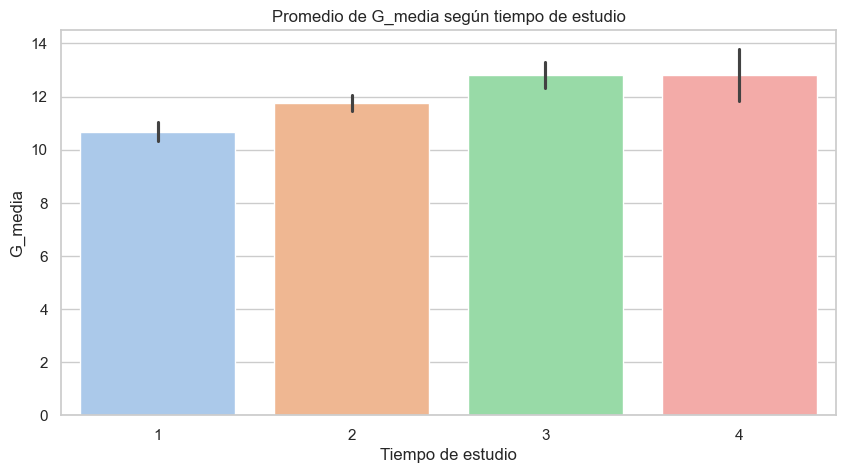

C:\Users\miria\AppData\Local\Temp\ipykernel_12068\3634870170.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="failures", y="G_media", palette="viridis")


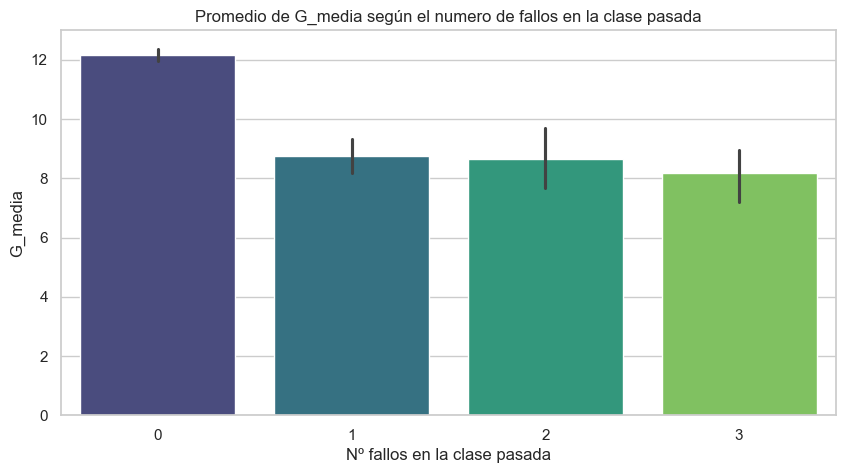

C:\Users\miria\AppData\Local\Temp\ipykernel_12068\3634870170.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="higher", y="G_media", palette="viridis")


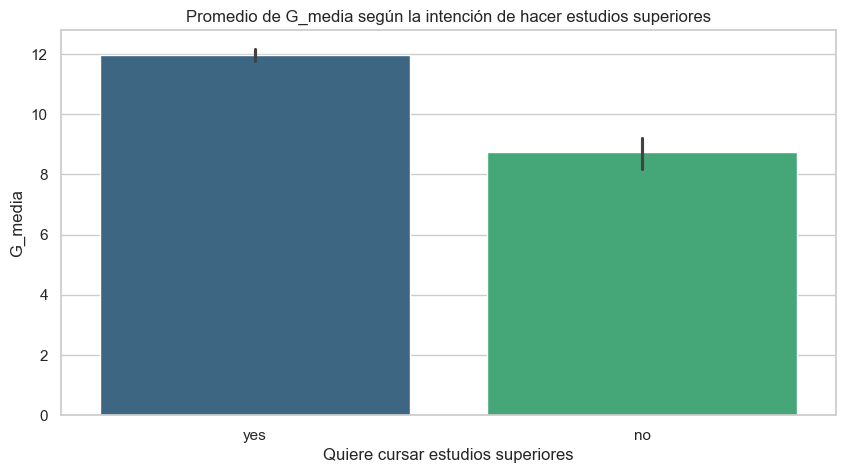

In [9]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="studytime", y="G_media", palette="pastel")
plt.title("Promedio de G_media según tiempo de estudio")
plt.xlabel("Tiempo de estudio")
plt.ylabel("G_media")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=df, x="failures", y="G_media", palette="viridis")
plt.title("Promedio de G_media según el numero de fallos en la clase pasada")
plt.xlabel("Nº fallos en la clase pasada")
plt.ylabel("G_media")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=df, x="higher", y="G_media", palette="viridis")
plt.title("Promedio de G_media según la intención de hacer estudios superiores")
plt.xlabel("Quiere cursar estudios superiores")
plt.ylabel("G_media")
plt.show()

Las tres gráficas analizan distintos factores que influyen en el rendimiento académico medido por la G_media (nota promedio). La primera gráfica muestra una relación positiva pero débil entre el tiempo de estudio y el rendimiento: si bien las notas tienden a mejorar con más horas de dedicación, la dispersión indica que otros factores intervienen significativamente. La segunda gráfica revela una correlación negativa más clara: a mayor número de fallos en la clase pasada, menor es la G_media, sugiriendo que el historial de dificultades académicas es un predictor relevante del desempeño futuro. La tercera gráfica presenta la diferencia más marcada: los estudiantes que manifiestan intención de cursar estudios superiores (yes) tienen una G_media notablemente más alta que quienes no (no), lo que subraya la motivación y las aspiraciones educativas como factores clave en el éxito académico. En conjunto, estos hallazgos destacan que, además del esfuerzo cuantificable (horas de estudio), aspectos actitudinales y de historial académico previo son determinantes en el rendimiento estudiantil.

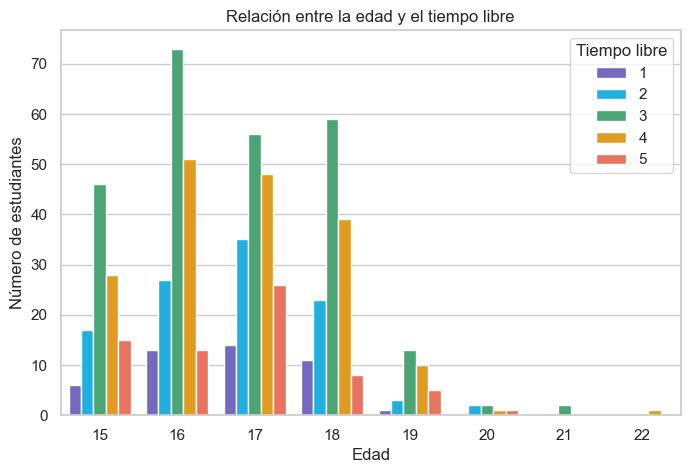

In [10]:
plt.figure(figsize=(8,5))
paleta = ["#6A5ACD", "#00BFFF", "#3CB371", "#FFA500", "#FF6347"]
sns.countplot(data=df, x="age", hue="freetime", palette=paleta)
plt.title("Relación entre la edad y el tiempo libre")
plt.xlabel("Edad")
plt.ylabel("Número de estudiantes")
plt.legend(title="Tiempo libre")
plt.show()


El código utiliza `sns.countplot` para visualizar cómo se distribuye el tiempo libre (freetime) de los estudiantes según su edad. La variable age se coloca en el eje X, mientras que freetime se usa como variable de agrupación para mostrar, para cada edad, cuántos estudiantes pertenecen a cada nivel de tiempo libre (de 1 a 5). De esta forma, el gráfico permite comparar de manera sencilla si ciertos grupos de edad tienden a tener más o menos tiempo libre y si existe algún patrón o diferencia relevante entre edades. Además, para dar un gráfico mas personalizados creamos nuestra propia paleta de colores. 

El gráfico muestra que la mayoría de los estudiantes del dataset tienen entre 15 y 18 años, por lo que estos grupos dominan visualmente la distribución. Dentro de estas edades, el nivel de tiempo libre “3” es claramente el más común, seguido de los niveles “4” y “2”, lo que sugiere que la mayoría de los adolescentes reportan niveles moderados de tiempo libre. A partir de los 19 años, el número de estudiantes disminuye drásticamente, lo que explica las barras muy bajas en esas edades y evita sacar conclusiones fuertes sobre esos grupos. No se observa un patrón que indique que el tiempo libre cambie significativamente con la edad: tanto jóvenes como mayores mantienen una distribución similar, con predominio del nivel 3. En resumen, la edad no parece influir de manera clara en la cantidad de tiempo libre, y las diferencias observadas se deben principalmente al tamaño desigual de los grupos de edad en la muestra.

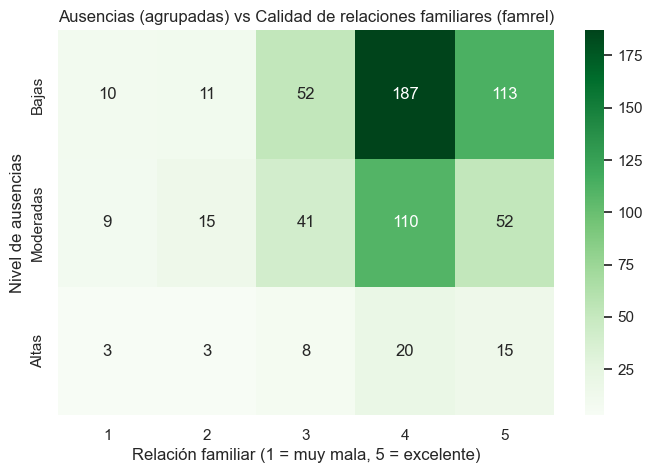

In [11]:
df["absences_group"] = pd.cut(
    df["absences"],
    bins=[-1, 3, 10, 100],
    labels=["Bajas", "Moderadas", "Altas"]
)

tabla = pd.crosstab(df["absences_group"], df["famrel"])

plt.figure(figsize=(8,5))
sns.heatmap(tabla, annot=True, cmap="Greens", fmt="d")
plt.title("Ausencias (agrupadas) vs Calidad de relaciones familiares (famrel)")
plt.xlabel("Relación familiar (1 = muy mala, 5 = excelente)")
plt.ylabel("Nivel de ausencias")
plt.show()


El código agrupa la variable absences en tres niveles de ausencias (Bajas, Moderadas y Altas) utilizando `pd.cut` para transformar una variable numérica continua en una categórica interpretable. Después, `pd.crosstab` genera una tabla de frecuencias cruzando estos niveles con la calidad de relaciones familiares (famrel), que se mide del 1 al 5. Finalmente, el heatmap permite visualizar cómo se distribuyen las ausencias según la percepción de la relación familiar; los colores más intensos indican combinaciones más frecuentes, facilitando detectar patrones entre ambas variables.

Como comentamos antes la falta de asistencia a las clases podriamos considerarlo a priori un factor clave para las clasificaciones de los estudiantes y un factor que podria determinar la ausencia de estos podria ser una mala relación con sus padres por ello hemos querido realizar este gráfico para ver como se relacionan estas dos variables. El gráfico muestra claramente que la mayoría de los estudiantes se concentran en dos grupos: ausencias bajas y relaciones familiares buenas o excelentes (4–5), donde se observan valores como 187 y 113, lo que indica que quienes reportan relaciones familiares positivas tienden a faltar menos. En el grupo de ausencias moderadas ocurre un patrón similar: la mayor densidad nuevamente aparece en niveles de relación familiar altos (110 y 52). Por otro lado, aunque en el grupo de Altas ausencias los valores absolutos sean bajos (por ejemplo, 3, 3, 8, 20, 15), esto no implica que no haya relación; simplemente el grupo de estudiantes con ausencias muy elevadas es muy pequeño en el dataset. Lo importante es compararlo proporcionalmente: dentro del grupo “Altas”, el mayor valor (20) ocurre en relaciones familiares de nivel 4, y el segundo mayor (15) en nivel 5, lo que refleja que entre quienes faltan mucho, las relaciones familiares se concentran en los niveles más bajos. De forma general, el patrón dominante del heatmap sugiere que la calidad de las relaciones familiares no se asocia fuertemente con un aumento de las ausencias, ya que tanto en bajas, moderadas como altas ausencias, los niveles 4 y 5 siguen siendo los más frecuentes de manera consistente, indicando que probablemente hay otros factores más determinantes en el absentismo escolar.

# 3.  Técnicas de reducción de la dimensión

## 3.1 PCA

El Análisis de Componentes Principales (PCA) es una técnica de reducción de la dimensionalidad que permite resumir la información contenida en un conjunto amplio de variables correlacionadas en un número menor de componentes no correlacionados, conservando la mayor parte de la variabilidad del conjunto de datos. Su objetivo principal no es la predicción, sino la exploración de la estructura interna de los datos y la identificación de patrones latentes. En este estudio, se incluyen tanto variables numéricas como variables ordinales, ya que estas últimas presentan un orden natural (por ejemplo, niveles educativos, frecuencia o intensidad de comportamientos) que puede interpretarse cuantitativamente y, por tanto, es coherente tratarlas como variables numéricas dentro del PCA, especialmente tras una estandarización previa. No se aplica one-hot encoding a las variables ordinales porque dicha transformación rompería ese orden inherente y aumentaría artificialmente la dimensionalidad del espacio, dificultando la interpretación de los componentes. En cambio, mantenerlas como variables numéricas permite que el PCA capture gradientes y relaciones continuas entre niveles, ofreciendo una representación más fiel y parsimoniosa de la información relevante para comprender el rendimiento académico de los estudiantes.


VARIANZA EXPLICADA PCA

    Componente  Varianza_explicada  Varianza_acumulada
0            1            0.174191            0.174191
1            2            0.143617            0.317807
2            3            0.102014            0.419821
3            4            0.088674            0.508495
4            5            0.081538            0.590033
5            6            0.072463            0.662496
6            7            0.066973            0.729470
7            8            0.065241            0.794711
8            9            0.060228            0.854939
9           10            0.049641            0.904580
10          11            0.043038            0.947618
11          12            0.027878            0.975496
12          13            0.024504            1.000000


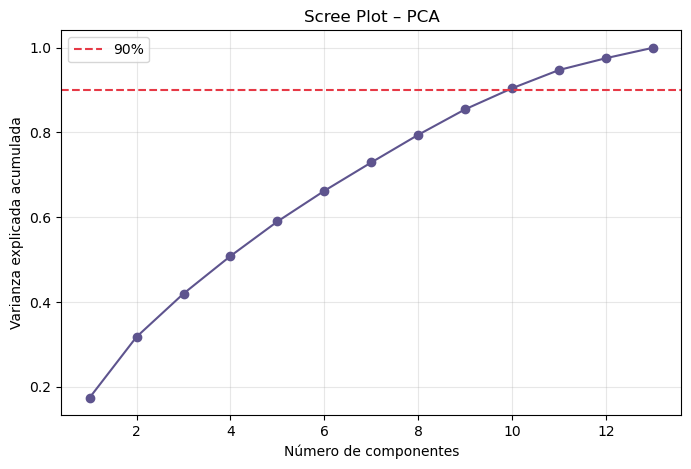

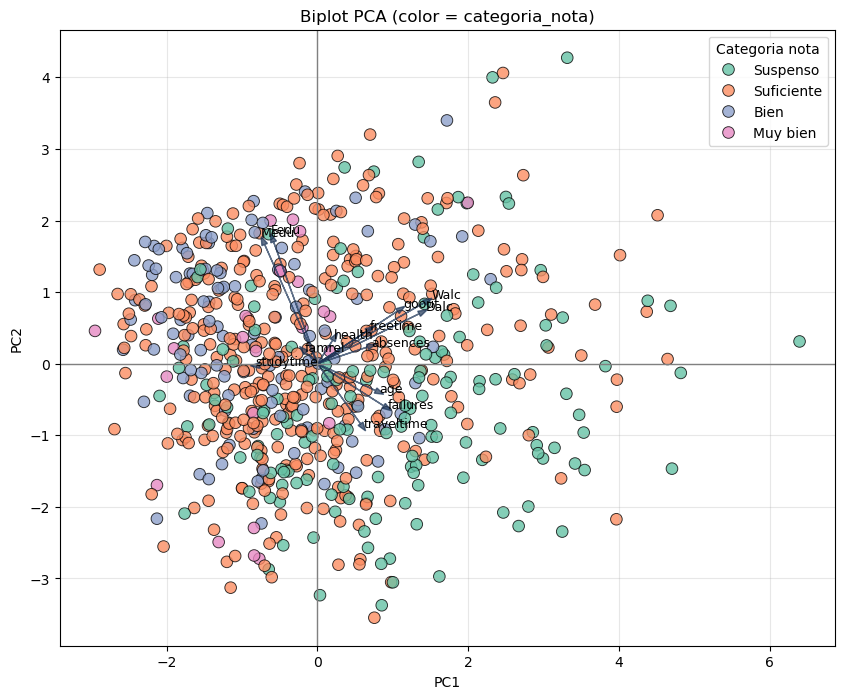

C:\Users\miria\AppData\Local\Temp\ipykernel_14000\4276513663.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Categoria nota")


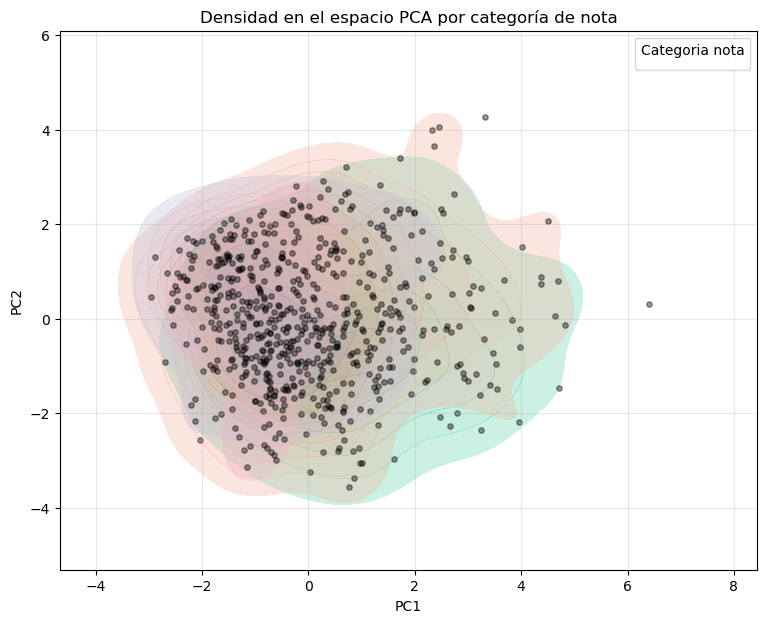

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

vars_pca = [
    "age", "absences",
    "Medu", "Fedu", "traveltime", "studytime", "failures",
    "famrel", "freetime", "goout", "Dalc", "Walc", "health"
]

X = df[vars_pca].copy()
y = df["categoria_nota"].astype(str)  # categórica

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

scores = X_pca[:, :2]
loadings = pca.components_[:2].T

tabla_pca = pd.DataFrame({
    "Componente": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "Varianza_explicada": pca.explained_variance_ratio_,
    "Varianza_acumulada": np.cumsum(pca.explained_variance_ratio_)
})

print("\nVARIANZA EXPLICADA PCA\n")
print(tabla_pca)

plt.figure(figsize=(8,5))
plt.plot(
    tabla_pca["Componente"],
    tabla_pca["Varianza_acumulada"],
    marker="o",
    color="#5E548E"
)
plt.axhline(0.90, color="#E63946", linestyle="--", label="90%")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada acumulada")
plt.title("Scree Plot – PCA")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10,8))

sns.scatterplot(
    x=scores[:,0],
    y=scores[:,1],
    hue=y,
    palette="Set2",
    edgecolor="black",
    s=70,
    alpha=0.8
)

for i, var in enumerate(vars_pca):
    plt.arrow(
        0, 0,
        loadings[i,0]*3,
        loadings[i,1]*3,
        color="#1D3557",
        alpha=0.7,
        head_width=0.08
    )
    plt.text(
        loadings[i,0]*3.2,
        loadings[i,1]*3.2,
        var,
        fontsize=9
    )

plt.axhline(0, color="grey", lw=1)
plt.axvline(0, color="grey", lw=1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biplot PCA (color = categoria_nota)")
plt.legend(title="Categoria nota")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9,7))

sns.kdeplot(
    x=scores[:,0],
    y=scores[:,1],
    hue=y,
    fill=True,
    palette="Dark2",
    alpha=0.35,
    thresh=0.05
)

plt.scatter(
    scores[:,0],
    scores[:,1],
    c="black",
    s=15,
    alpha=0.4
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Densidad en el espacio PCA por categoría de nota")
plt.grid(True, alpha=0.3)
plt.legend(title="Categoria nota")
plt.show()


El código realiza un análisis de componentes principales  para reducir la dimensionalidad de un conjunto de 13 variables numéricas y ordinales, excluyendo las notas individuales G1, G2 y G3. Primero, estandariza los datos para evitar sesgos por escalas diferentes. Luego, aplica PCA para extraer componentes principales y calcula la varianza explicada por cada uno. Genera tres visualizaciones clave: un scree plot para decidir el número óptimo de componentes (basado en la varianza acumulada), un biplot que superpone las proyecciones de los individuos con las direcciones de las variables originales, y un gráfico de densidad que muestra cómo se distribuye el rendimiento académico en el espacio bidimensional de los dos primeros componentes principales. El objetivo es identificar patrones y relaciones entre las variables predictoras y la variable objetivo G_media en un espacio reducido.

Los resultados del PCA revelan que los dos primeros componentes principales capturan una parte significativa de la varianza total de los datos, aunque el scree plot indica que se necesitarían más de dos componentes para alcanzar un nivel de explicación alto (por ejemplo, 90%). En el biplot, se observa que variables como failures, age y absences se asocian positivamente con el primer componente principal (PC1), mientras que Medu, Fedu y studytime lo hacen en dirección opuesta, sugiriendo que PC1 podría interpretarse como un eje que contrasta el riesgo académico (fracasos, edad avanzada, ausencias) con el apoyo educativo familiar y el esfuerzo. Por otro lado, variables como goout, Dalc y Walc parecen influir más en el segundo componente (PC2), relacionado con hábitos sociales y de ocio. La coloración por categoría en el biplot y el gráfico de densidad muestra que los estudiantes con mayores promedios tienden a agruparse en la región del espacio donde predominan variables de apoyo educativo (Medu, Fedu) y menor presencia de factores de riesgo. La densidad ponderada por categoría confirma que las zonas de alto rendimiento se concentran en valores negativos de PC1 (menos fracasos, más estudio) y valores moderados de PC2. En conclusión, el PCA permite visualizar cómo el rendimiento académico está fuertemente vinculado a un perfil de bajo riesgo académico y alto apoyo familiar, mientras que los hábitos sociales muestran una influencia secundaria en la distribución de los promedios.

## 3.2 MDS

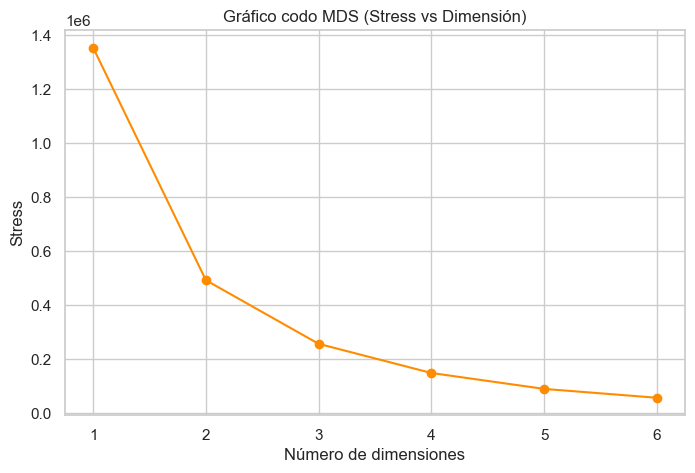

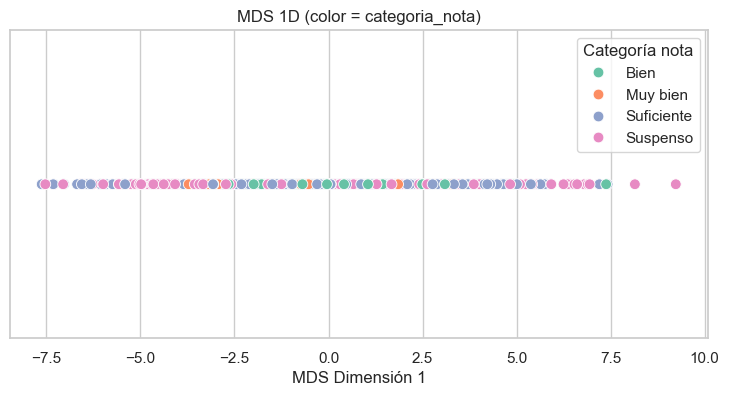

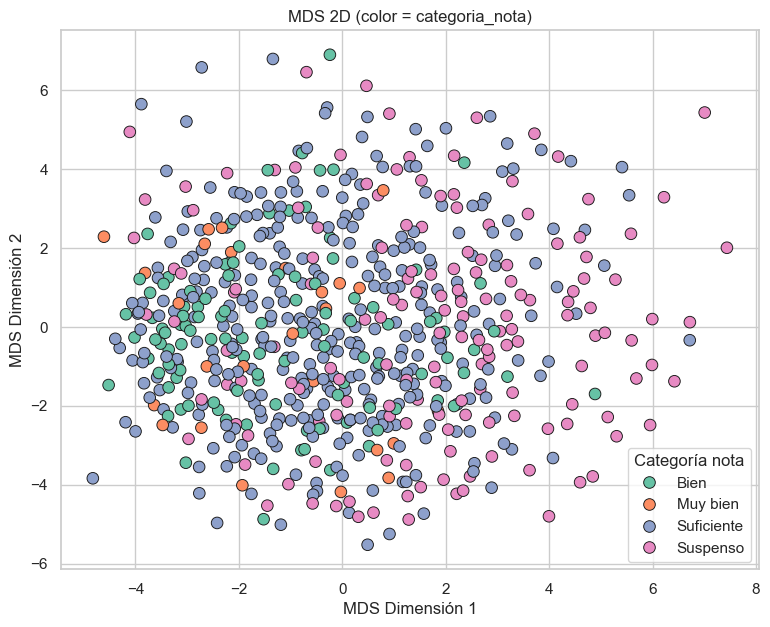

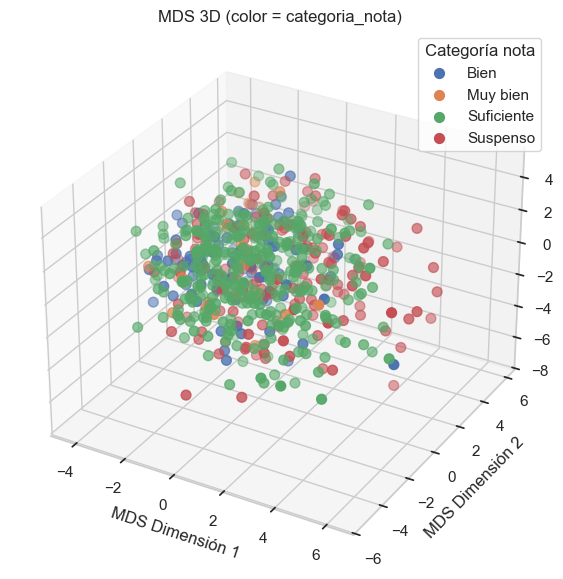

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.manifold import MDS
from mpl_toolkits.mplot3d import Axes3D

vars_mds = [
    "age", "absences",
    "Medu", "Fedu", "traveltime", "studytime", "failures",
    "famrel", "freetime", "goout", "Dalc", "Walc", "health"
]

X = df[vars_mds].copy()
y = df["categoria_nota"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

stress = []
dims = range(1, 7)

for d in dims:
    mds = MDS(
        n_components=d,
        metric=True,
        random_state=42,
        normalized_stress="auto"
    )
    mds.fit(X_scaled)
    stress.append(mds.stress_)

plt.figure(figsize=(8,5))
plt.plot(dims, stress, marker="o", color="darkorange")
plt.xlabel("Número de dimensiones")
plt.ylabel("Stress")
plt.title("Gráfico codo MDS (Stress vs Dimensión)")
plt.grid(True)
plt.show()

mds_1d = MDS(
    n_components=1,
    metric=True,
    random_state=42,
    normalized_stress="auto"
)

X_mds_1d = mds_1d.fit_transform(X_scaled)

plt.figure(figsize=(9,4))
sns.scatterplot(
    x=X_mds_1d[:,0],
    y=np.zeros_like(X_mds_1d[:,0]),
    hue=y,
    palette="Set2",
    s=60
)
plt.yticks([])
plt.xlabel("MDS Dimensión 1")
plt.title("MDS 1D (color = categoria_nota)")
plt.legend(title="Categoría nota")
plt.grid(True)
plt.show()

mds_2d = MDS(
    n_components=2,
    metric=True,
    random_state=42,
    normalized_stress="auto"
)

X_mds_2d = mds_2d.fit_transform(X_scaled)

plt.figure(figsize=(9,7))
sns.scatterplot(
    x=X_mds_2d[:,0],
    y=X_mds_2d[:,1],
    hue=y,
    palette="Set2",
    s=70,
    edgecolor="k"
)
plt.xlabel("MDS Dimensión 1")
plt.ylabel("MDS Dimensión 2")
plt.title("MDS 2D (color = categoria_nota)")
plt.legend(title="Categoría nota")
plt.grid(True)
plt.show()

mds_3d = MDS(
    n_components=3,
    metric=True,
    random_state=42,
    normalized_stress="auto"
)

X_mds_3d = mds_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")

for i, cat in enumerate(le.classes_):
    ax.scatter(
        X_mds_3d[y_enc == i, 0],
        X_mds_3d[y_enc == i, 1],
        X_mds_3d[y_enc == i, 2],
        label=cat,
        s=50
    )

ax.set_xlabel("MDS Dimensión 1")
ax.set_ylabel("MDS Dimensión 2")
ax.set_zlabel("MDS Dimensión 3")
ax.set_title("MDS 3D (color = categoria_nota)")
ax.legend(title="Categoría nota")

plt.show()


El código realiza un Escalamiento Multidimensional (MDS), una técnica de reducción de dimensionalidad no lineal que busca preservar las distancias (o disimilitudes) originales entre los puntos de datos en un espacio de menor dimensión. A diferencia del PCA, que se basa en la covarianza, el MDS minimiza una función de estrés (stress) que mide la discrepancia entre las distancias originales y las distancias en el espacio reducido. El proceso comienza calculando una matriz de distancias entre las observaciones (usando métricas como la distancia euclidiana), luego aplica MDS para proyectar los datos en 1 y 2 dimensiones, evaluando el estrés para diferentes dimensiones mediante un gráfico codo. Finalmente, visualiza las proyecciones coloreando los puntos según la variable objetivo categoria_nota, lo que permite observar cómo se distribuyen los niveles de rendimiento académico en los espacios reducidos.

El gráfico de codo (Stress vs. Número de dimensiones) muestra que el estrés disminuye rápidamente al aumentar las dimensiones, estabilizándose a partir de 2-3 dimensiones. Esto sugiere que una representación en 2D es razonable para preservar la estructura de disimilitud sin una pérdida significativa de información, mientras que el uso de 3 dimensiones reduciría aún más el estrés, aunque con una ganancia marginal en interpretabilidad.

En la proyección 1D, se observa una distribución amplia de los estudiantes a lo largo del MDS Dimension 1, con una coloración por categoría de nota que indica cierta agrupación: los estudiantes de categoría "Muy bien" (color rojo claro) tienden a concentrarse hacia el extremo izquierdo, mientras que los de "Suspenso" se dispersan más hacia la derecha. Esto sugiere que la primera dimensión captura parte de la variabilidad relacionada con el rendimiento académico.

En la representación 2D, la distribución es más dispersa y se aprecia mejor la formación de agrupaciones naturales: los estudiantes con "Muy bien" y "Bien" se concentran principalmente en la región central-izquierda del gráfico, mientras que los de "Suficiente" y "Suspenso" tienden a ubicarse hacia la periferia derecha y superior. La MDS Dimension 2 incorpora información adicional, posiblemente vinculada a factores no lineales o interacciones entre variables no capturadas en análisis previos.

En la proyección 3D, aunque no se muestra visualmente en detalle, se espera una mayor separación entre categorías debido a la reducción adicional del estrés. La tercera dimensión podría reflejar atributos más sutiles o complejos de los datos, mejorando la discriminación entre grupos, especialmente entre "Suficiente" y "Bien", que en 2D aún presentan cierta superposición.



## 3.3 Comparación

El Análisis de Componentes Principales (PCA) y el Escalamiento Multidimensional (MDS) son técnicas de reducción de dimensionalidad con enfoques complementarios. El PCA es un método lineal basado en la matriz de covarianzas que busca maximizar la varianza explicada, lo que permite obtener componentes fácilmente interpretables en función de las variables originales; en este estudio, el primer componente se interpreta claramente como un eje que contrapone factores de riesgo académico (failures, age, absences) frente a variables de apoyo educativo y esfuerzo (Medu, Fedu, studytime), facilitando la explicación del rendimiento académico medido por G_media. En cambio, el MDS no se basa en la varianza sino en la preservación de las distancias entre observaciones, minimizando una función de estrés, lo que lo hace especialmente adecuado para explorar la estructura global de los datos y detectar agrupaciones, incluso cuando existen relaciones no lineales. Las proyecciones del MDS muestran una separación más clara entre estudiantes de distinto rendimiento con solo 2 o 3 dimensiones, aunque a costa de una menor interpretabilidad, ya que sus dimensiones no pueden vincularse directamente a variables concretas. En conjunto, el PCA destaca por su capacidad explicativa y el MDS por su potencia exploratoria.

| Aspecto                       | PCA                                            | MDS                                                   |
|:------------------------------|:-----------------------------------------------|:------------------------------------------------------|
| Tipo de técnica               | Reducción de dimensionalidad lineal            | Reducción de dimensionalidad no lineal                |
| Relaciones que captura        | Relaciones lineales                            | Relaciones lineales y no lineales                     |
| Criterio de optimización      | Maximiza la varianza explicada                 | Minimiza el stress (distancias)                       |
| Interpretabilidad             | Alta (componentes interpretables)              | Baja (dimensiones abstractas)                         |
| Número de dimensiones necesarias | Más componentes para alta varianza             | Pocas dimensiones (2–3)                               |
| Relación con variables originales | Cargas factoriales claras                    | No directa                                            |
| Utilidad principal en este estudio | Explicar el impacto de factores educativos sobre G_media | Explorar la estructura y agrupación del rendimiento académico |

En el contexto de este trabajo, el PCA resulta más adecuado cuando el objetivo es interpretar y explicar el rendimiento académico (G_media) a partir de variables educativas y familiares concretas, ya que ofrece componentes claramente interpretables y directamente vinculables a los factores de estudio. En cambio, el MDS es superior como herramienta exploratoria, ya que permite visualizar con mayor nitidez la estructura global de similitud entre estudiantes y detectar agrupaciones de rendimiento incluso en presencia de relaciones no lineales. Por tanto, no se trata de técnicas excluyentes, sino complementarias: el PCA aporta explicación y el MDS aporta exploración y validación estructural de los patrones observados.


# 4. Clustering


## 4.1 K-Medias

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

vars_numericas = ["age", "absences"]

vars_ordinales = [
    "Medu", "Fedu",
    "traveltime", "studytime",
    "failures",
    "famrel", "freetime", "goout",
    "Dalc", "Walc",
    "health"
]

df_cluster = df[vars_numericas + vars_ordinales].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

inertia_values = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

silhouette_vals = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    silhouette_vals.append(sil)


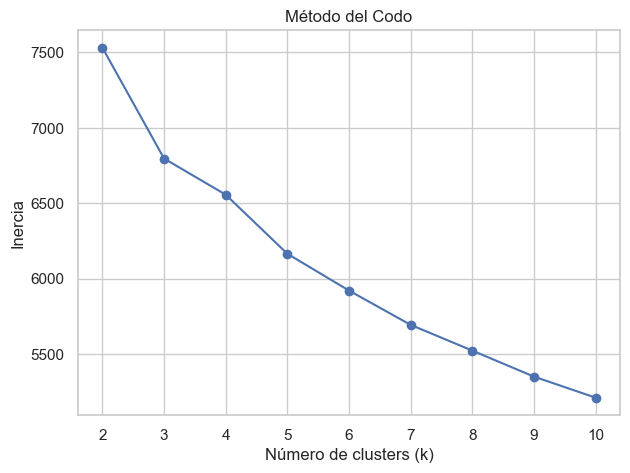

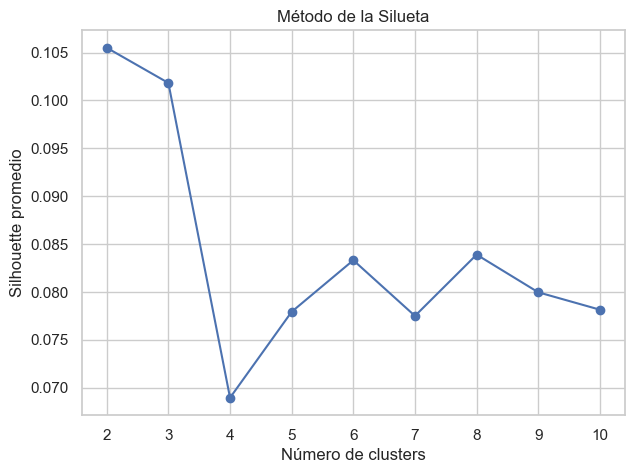

In [23]:
plt.figure(figsize=(7,5))
plt.plot(K, inertia_values, marker='o')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,5))
plt.plot(K, silhouette_vals, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette promedio")
plt.title("Método de la Silueta")
plt.grid(True)
plt.show()

El código realiza un proceso completo de clustering utilizando K-means. Primero selecciona variables numéricas y ordinales del dataset y crea un subconjunto con ellas. Luego estandariza todas las variables mediante StandardScaler para evitar que las diferencias de escala influyan en el algoritmo. A continuación aplica dos métodos para determinar un número adecuado de clusters. Con el Método del Codo, calcula la inercia (suma de distancias internas) para valores de k entre 2 y 10, graficándolos para observar dónde la reducción de inercia comienza a disminuir de forma notable. Después utiliza el Método de la Silueta, calculando el puntaje promedio de silueta para cada k en ese mismo rango. Ambos métodos permiten evaluar la cohesión interna y la separación externa de los clusters. Finalmente, genera dos gráficas que ayudan a visualizar y comparar los resultados.

En la gráfica del Método del Codo, la inercia disminuye conforme aumenta el número de clusters, pero el descenso empieza a volverse menos pronunciado alrededor de k = 4 o 5, indicando un posible “codo”. Por otro lado, en el Método de la Silueta, el puntaje más alto corresponde a k = 2, seguido muy de cerca por k = 3; sin embargo, a partir de k=4 el puntaje cae de manera significativa y luego fluctúa sin mejorar. Esto sugiere que las mejores separaciones entre grupos ocurren con pocos clusters. Combinando ambas métricas, el valor más equilibrado suele ser aquel que logra una buena silueta sin sacrificar demasiado la estructura interna: en este caso, k = 3 se presenta como un punto intermedio razonable, pues mantiene una buena calidad de separación y un codo visible sin caer en soluciones demasiado simples como k = 2.

In [ ]:
best_k = 3   

kmeans = KMeans(n_clusters=best_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

df_plot = df_cluster.copy()
df_plot["cluster"] = cluster_labels

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)



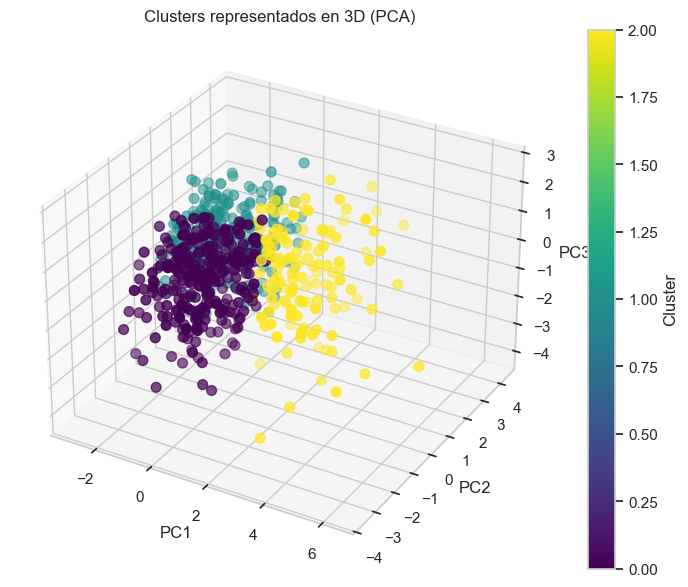

In [25]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2],
                c=cluster_labels, cmap='viridis', s=50)

ax.set_title("Clusters representados en 3D (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

fig.colorbar(sc, label="Cluster")
plt.show()

En este bloque de código se entrena el algoritmo K-Means utilizando el número de clusters considerado óptimo según los métodos del codo y la silueta, fijado aquí en k = 3. Tras ajustar el modelo sobre los datos estandarizados, se generan las etiquetas de cluster para cada estudiante y se añaden al dataframe. Luego se crea un pairplot donde las variables numéricas y ordinales seleccionadas se muestran coloreadas según el grupo asignado, permitiendo observar visualmente qué patrones separan a los clusters. Finalmente, se aplica PCA para reducir los datos a tres componentes principales y representar los clusters en un espacio tridimensional, facilitando una interpretación visual más clara de cómo se distribuyen los grupos en función de su variabilidad conjunta.

Los gráficos muestran que los estudiantes se dividen en tres perfiles diferenciados según sus características numéricas y ordinales, lo que tiene implicaciones directas para el estudio del rendimiento académico. En el pairplot, los clusters revelan diferencias en edad y ausencias, que ya anticipan comportamientos distintos: un grupo con más ausencias, otro más joven y con menos variabilidad, y un tercero intermedio. En la representación 3D mediante PCA se aprecia aún más claramente la separación entre clusters, indicando que los estudiantes presentan patrones consistentes y estructurados en sus hábitos, salud, salidas, consumo de alcohol o nivel educativo familiar. Esto es relevante para nuestro trabajo porque estos grupos pueden estar asociados a diferencias en las notas finales: los clusters podrían reflejar perfiles de riesgo académico, patrones de disciplina o niveles de apoyo familiar. Analizar posteriormente la relación entre cluster y rendimiento académico permitirá identificar qué tipos de estudiantes tienden a obtener mejores o peores calificaciones y qué variables explican estas diferencias.


MEDIA DE G_media POR CLUSTER 



C:\Users\miria\AppData\Local\Temp\ipykernel_12068\982722619.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cluster, x="cluster", y="G_media", palette="viridis")


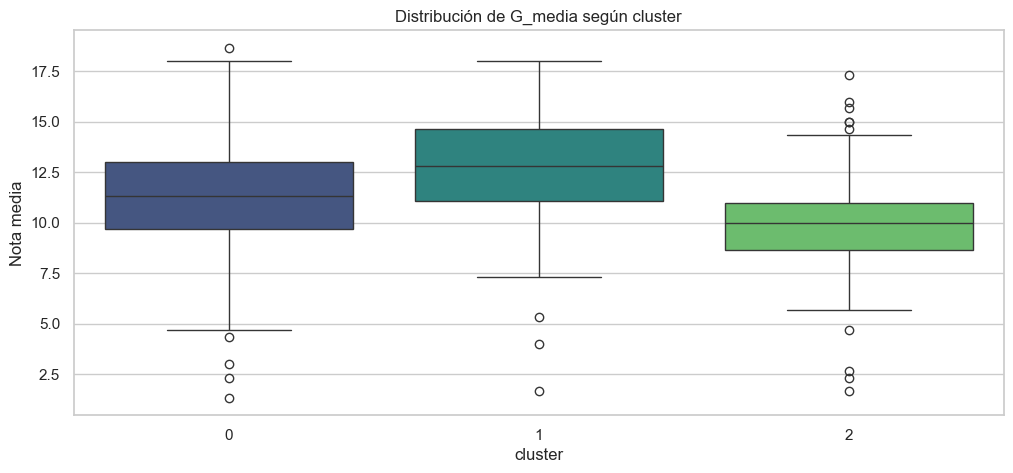

C:\Users\miria\AppData\Local\Temp\ipykernel_12068\982722619.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_cluster, x="cluster", y="G_media", palette="Set2")


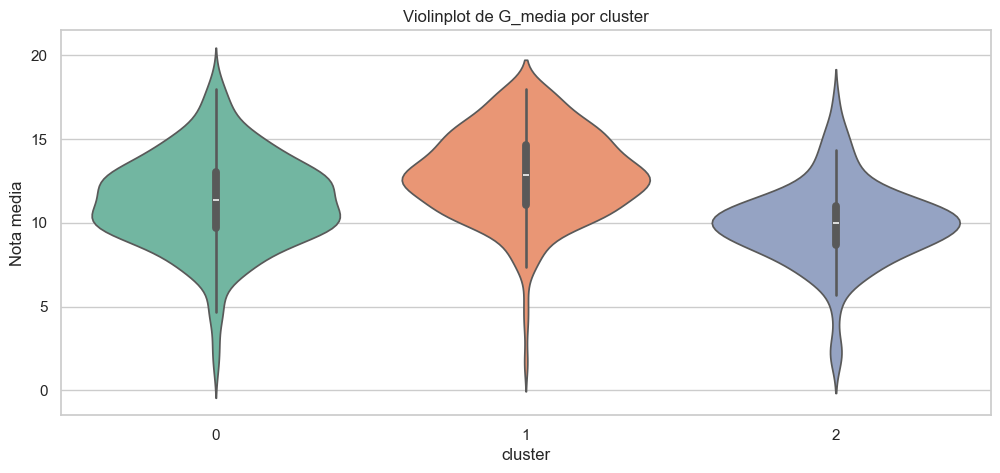

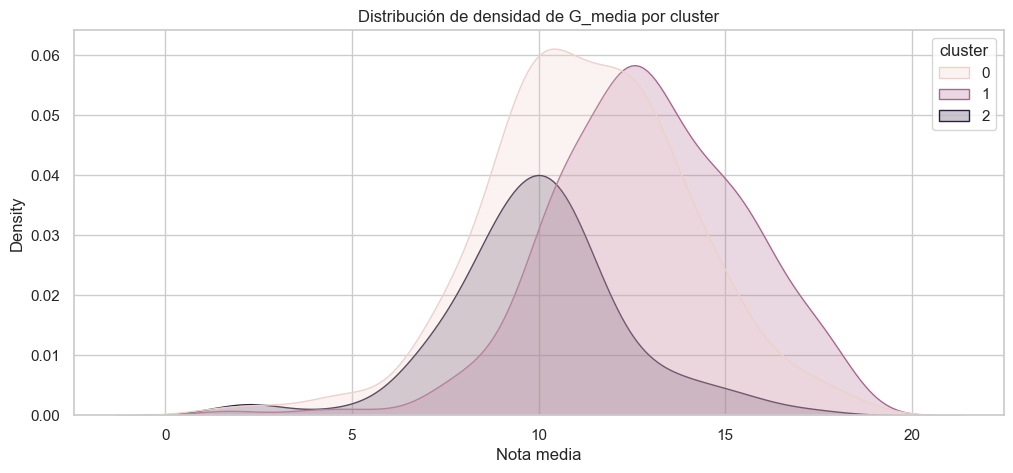

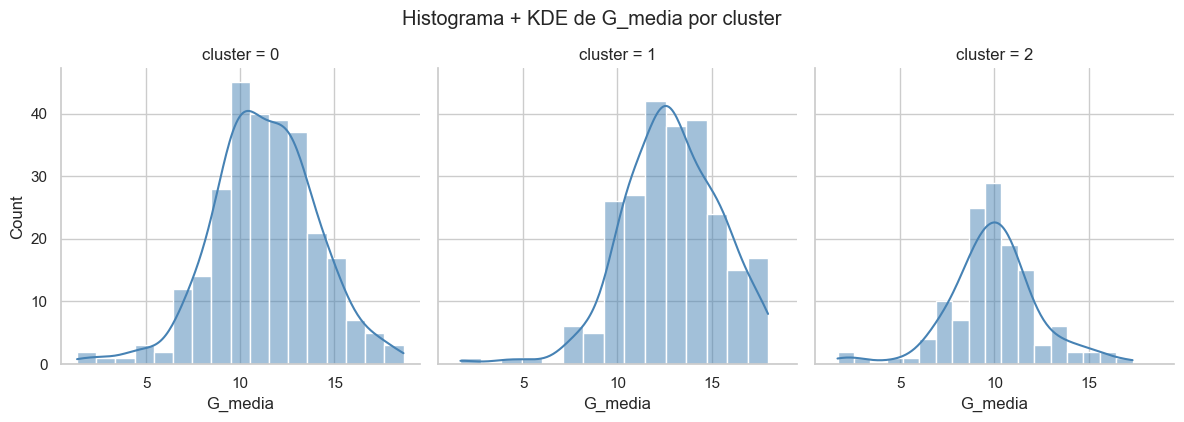

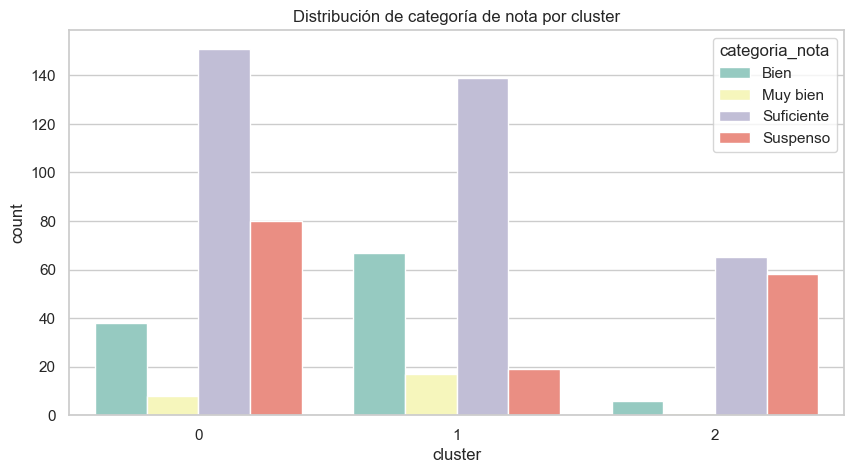

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_cluster = df.copy()     
df_cluster["cluster"] = cluster_labels  

df_cluster["G_media"] = df["G_media"]
df_cluster["categoria_nota"] = df["categoria_nota"]

tabla_notas = df_cluster.groupby("cluster")[["G_media"]].mean().round(2)
print("\nMEDIA DE G_media POR CLUSTER \n")
plt.figure(figsize=(12,5))
sns.boxplot(data=df_cluster, x="cluster", y="G_media", palette="viridis")
plt.title("Distribución de G_media según cluster")
plt.ylabel("Nota media")
plt.show()

plt.figure(figsize=(12,5))
sns.violinplot(data=df_cluster, x="cluster", y="G_media", palette="Set2")
plt.title("Violinplot de G_media por cluster")
plt.ylabel("Nota media")
plt.show()

plt.figure(figsize=(12,5))
sns.kdeplot(data=df_cluster, x="G_media", hue="cluster", fill=True)
plt.title("Distribución de densidad de G_media por cluster")
plt.xlabel("Nota media")
plt.show()

g = sns.FacetGrid(df_cluster, col="cluster", height=4)
g.map(sns.histplot, "G_media", kde=True, color="steelblue")
plt.suptitle("Histograma + KDE de G_media por cluster", y=1.05)
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(data=df_cluster, x="cluster", hue="categoria_nota", palette="Set3")
plt.title("Distribución de categoría de nota por cluster")
plt.show()


Los gráficos muestran cómo varía la nota media (G_media) entre los tres clusters obtenidos mediante K-means. Los boxplots y violines indican diferencias claras en el nivel académico de cada grupo: el cluster 1 presenta las notas medias más altas y una distribución menos dispersa, el cluster 0 se sitúa en un nivel intermedio y el cluster 2 recoge a los estudiantes con peores resultados. Las distribuciones KDE y los histogramas confirman estas diferencias al mostrar picos bien definidos en distintas zonas del rango de notas. Finalmente, el gráfico de barras con categorías cualitativas (“Bien”, “Muy bien”, “Suficiente”, “Suspenso”) refuerza esta separación: el cluster 1 agrupa mayoritariamente a estudiantes con buenas o muy buenas calificaciones, mientras que el cluster 2 concentra más suspensos y el cluster 0 queda en una posición intermedia.

Dado que el clustering se construyó usando variables relacionadas con condiciones personales y académicas de los estudiantes (edad, ausencias, nivel educativo familiar, tiempo de estudio, hábitos, salud, etc.), estos resultados indican que el rendimiento académico no es aleatorio, sino que tiende a agruparse según perfiles específicos detectados por K-means. Así, cada cluster representa un tipo de estudiante: aquellos con mejores hábitos y contextos favorables (cluster 1), un grupo medio con condiciones mixtas (cluster 0) y un grupo más vulnerable académicamente (cluster 2). Esto significa que nuestro análisis no solo diferencia niveles de rendimiento, sino que permite identificar patrones asociados a estas variables. En consecuencia, el clustering puede orientar intervenciones educativas: apoyo reforzado al cluster 2, estrategias de motivación y asistencia para el cluster 0, y mantenimiento o potenciación de hábitos positivos en el cluster 1.

# 5. Árboles de decision 


Mejores hiperparámetros encontrados:
{'criterion': 'entropy', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 30, 'min_samples_split': 2}

Mejor accuracy CV: 0.6344


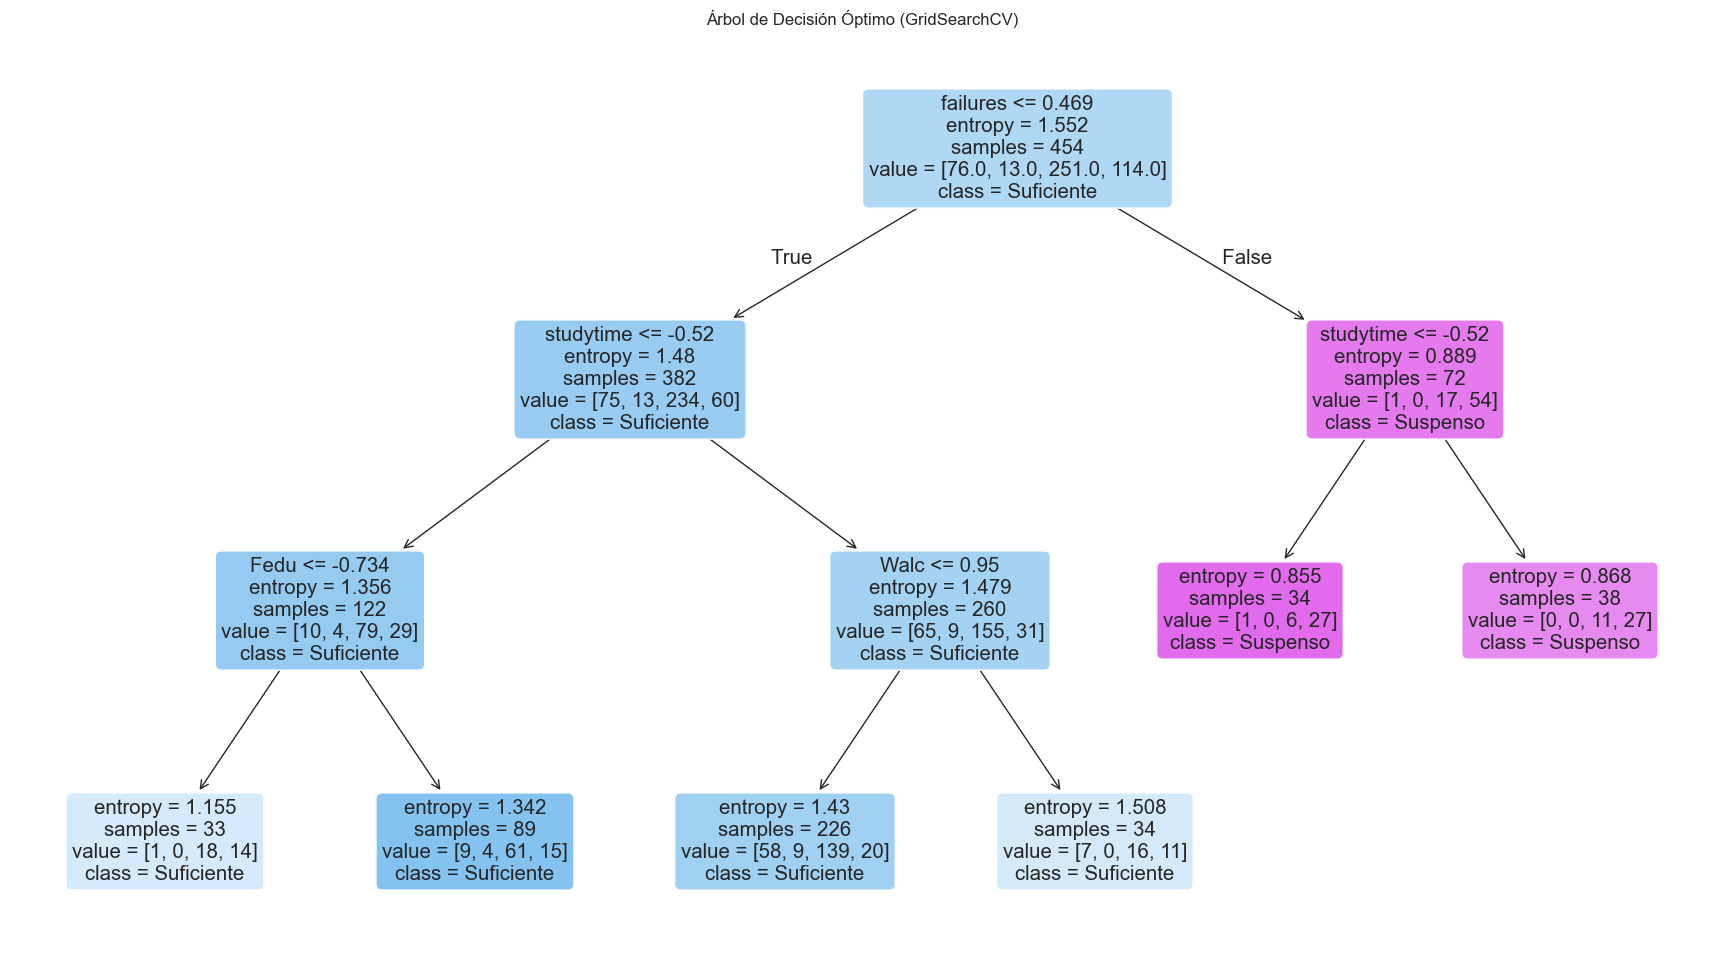

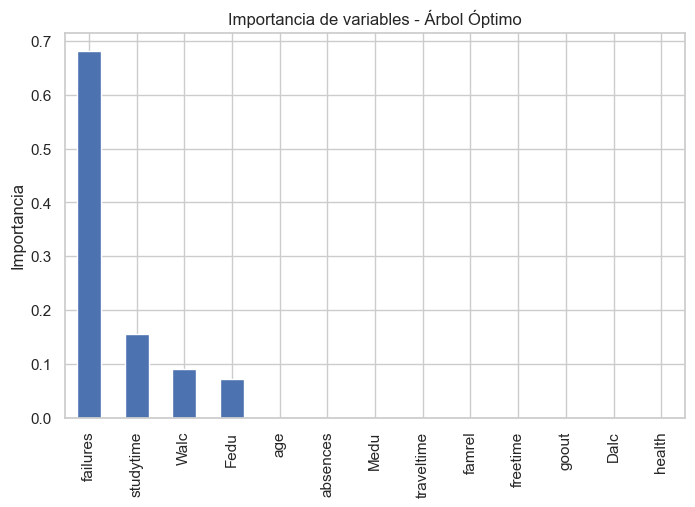

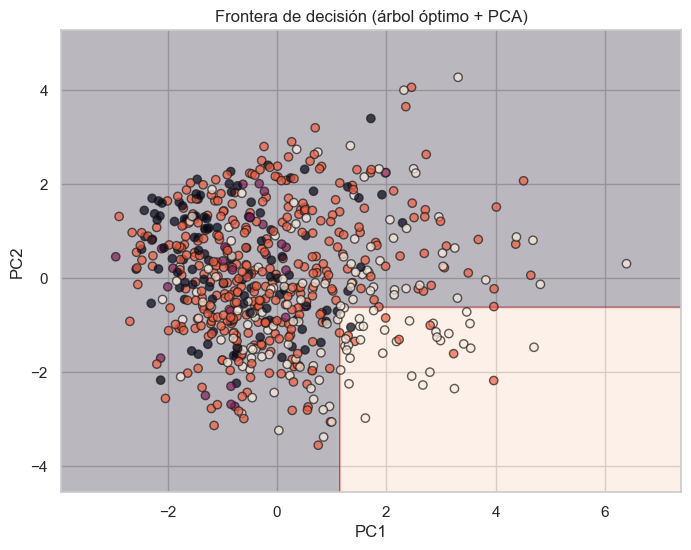

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

vars_modelo = [
    "age", "absences",
    "Medu", "Fedu", "traveltime", "studytime", "failures",
    "famrel", "freetime", "goout", "Dalc", "Walc", "health"
]

X = df[vars_modelo].copy()
y = df["categoria_nota"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.3, random_state=42
)

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 3, 4, 5, 6, 8, 10, 12],
    "min_samples_leaf": [1, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "max_features": [None, "sqrt", "log2"]
}

dt = DecisionTreeClassifier(random_state=42)

grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train, y_train)

best_clf = grid.best_estimator_

print("\nMejores hiperparámetros encontrados:")
print(grid.best_params_)
print(f"\nMejor accuracy CV: {grid.best_score_:.4f}")

plt.figure(figsize=(22, 12))
plot_tree(
    best_clf,
    feature_names=vars_modelo,
    class_names=le.classes_,
    filled=True,
    rounded=True
)
plt.title("Árbol de Decisión Óptimo (GridSearchCV)")
plt.show()

importancias = pd.Series(
    best_clf.feature_importances_,
    index=vars_modelo
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importancias.plot(kind="bar")
plt.ylabel("Importancia")
plt.title("Importancia de variables - Árbol Óptimo")
plt.show()

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

best_clf_2d = DecisionTreeClassifier(**grid.best_params_, random_state=42)
best_clf_2d.fit(X_pca, y_enc)

x_min, x_max = X_pca[:,0].min() - 1, X_pca[:,0].max() + 1
y_min, y_max = X_pca[:,1].min() - 1, X_pca[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = best_clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_enc, edgecolor="k", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Frontera de decisión (árbol óptimo + PCA)")
plt.show()


El código implementa un modelo de clasificación mediante un árbol de decisión optimizado con GridSearchCV. Primero, se seleccionan variables numéricas y ordinales del dataset, se codifica la variable objetivo y se estandarizan los datos. Luego, se divide el conjunto en entrenamiento y prueba. A continuación, se realiza una búsqueda exhaustiva de hiperparámetros (como criterio de división, profundidad máxima, muestras mínimas por hoja, etc.) para encontrar la configuración óptima del árbol. Una vez encontrado el mejor modelo, se visualiza la estructura del árbol, se grafica la importancia de las variables y, finalmente, se proyectan los datos en dos dimensiones mediante PCA para visualizar las fronteras de decisión del modelo optimizado en un espacio reducido.

La primera gráfica es la representación del árbol de decisión óptimo, que muestra cómo el modelo realiza las divisiones basadas en variables como "failures" y "studytime", indicando la entropía y la distribución de las clases en cada nodo. El segundo gráfico es un gráfico de barras que ilustra la importancia relativa de las variables en el modelo, donde "failures" y "studytime" destacan como los predictores más relevantes. La tercera imagen muestra la frontera de decisión en un espacio bidimensional obtenido mediante PCA, donde los puntos representan las observaciones coloreadas por clase y las regiones sombreadas indican las áreas de clasificación del modelo, permitiendo visualizar cómo se separan las categorías en el espacio reducido.

# 6. Redes neuronales

Mejores hiperparámetros encontrados:
{'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (20,), 'learning_rate': 'constant'}

Mejor accuracy en CV: 0.5594

 Classification Report (Test) 

              precision    recall  f1-score   support

        Bien       0.18      0.18      0.18        33
    Muy bien       0.25      0.12      0.17         8
  Suficiente       0.56      0.60      0.58       107
    Suspenso       0.40      0.36      0.38        47

    accuracy                           0.45       195
   macro avg       0.35      0.32      0.33       195
weighted avg       0.44      0.45      0.45       195



c:\Users\miria\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


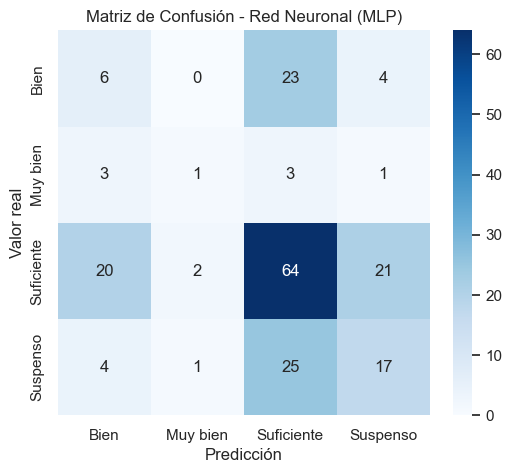

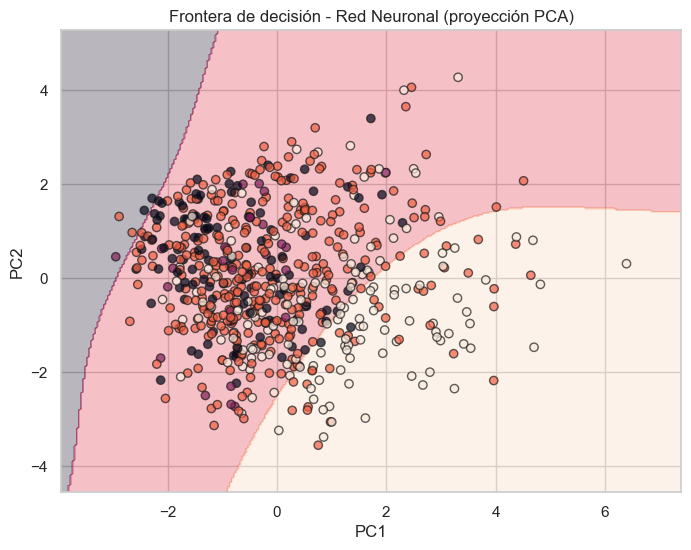

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA

vars_modelo = [
    "age", "absences",
    "Medu", "Fedu", "traveltime", "studytime", "failures",
    "famrel", "freetime", "goout", "Dalc", "Walc", "health"
]

X = df[vars_modelo].copy()
y = df["categoria_nota"]

le = LabelEncoder()
y_enc = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc,
    test_size=0.3,
    random_state=42,
    stratify=y_enc
)

mlp = MLPClassifier(
    max_iter=2000,
    random_state=42
)

param_grid = {
    "hidden_layer_sizes": [
        (10,), (20,), (30,),
        (20,10), (30,15), (40,20)
    ],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate": ["constant", "adaptive"]
}

grid = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_mlp = grid.best_estimator_

print("Mejores hiperparámetros encontrados:")
print(grid.best_params_)
print(f"\nMejor accuracy en CV: {grid.best_score_:.4f}")

y_pred = best_mlp.predict(X_test)

print("\n Classification Report (Test) \n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión - Red Neuronal (MLP)")
plt.show()

pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

mlp_2d = MLPClassifier(
    hidden_layer_sizes=grid.best_params_["hidden_layer_sizes"],
    activation=grid.best_params_["activation"],
    alpha=grid.best_params_["alpha"],
    learning_rate=grid.best_params_["learning_rate"],
    max_iter=2000,
    random_state=42
)

mlp_2d.fit(X_pca, y_enc)

x_min, x_max = X_pca[:,0].min() - 1, X_pca[:,0].max() + 1
y_min, y_max = X_pca[:,1].min() - 1, X_pca[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = mlp_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=y_enc, edgecolor="k", alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Frontera de decisión - Red Neuronal (proyección PCA)")
plt.show()


Este código implementa un clasificador basado en Redes Neuronales Artificiales (MLP - Perceptrón Multicapa) para predecir la categoría de nota académica ("categoria_nota") utilizando 13 variables predictoras relacionadas con características demográficas, educativas y hábitos personales. El proceso comienza con la preparación de datos: codificación de etiquetas, estandarización de características y división en conjuntos de entrenamiento y prueba. Luego, se realiza una búsqueda exhaustiva de hiperparámetros (GridSearchCV) para optimizar la arquitectura de la red (número de neuronas en capas ocultas, función de activación, regularización y tasa de aprendizaje). El modelo final se evalúa mediante un informe de clasificación y una matriz de confusión. Adicionalmente, se visualiza la frontera de decisión del MLP en un espacio bidimensional obtenido mediante PCA, lo que permite observar cómo el modelo separa las diferentes categorías de nota en un plano reducido.

Los resultados muestran que el modelo de red neuronal alcanzó una accuracy moderada del 55.94% en validación cruzada, utilizando como mejor configuración una única capa oculta de 20 neuronas, función de activación tanh, un nivel de regularización alto (alpha = 0.01) y una tasa de aprendizaje constante. En el conjunto de prueba, el rendimiento global disminuye hasta una accuracy del 45%, lo que indica limitaciones en la capacidad de generalización del modelo. El informe de clasificación evidencia un comportamiento desigual entre clases: la categoría “Suficiente” es la mejor identificada (precision = 0.56, recall = 0.60, F1 = 0.58), mientras que “Bien” y “Muy bien” presentan rendimientos bajos, especialmente esta última, con un recall reducido debido al escaso número de observaciones. La clase “Suspenso” muestra un desempeño intermedio, con confusión frecuente respecto a “Suficiente”, lo que sugiere fronteras difusas entre categorías adyacentes. En conjunto, estos resultados reflejan que la red neuronal logra capturar parcialmente los patrones del problema multiclase, pero la superposición entre clases y el desequilibrio en los datos dificultan una clasificación más precisa.

La red neuronal no predijo la categoría "Muy bien" debido al fuerte desbalance de clases, lo que no es un error sino una limitación relevante que enriquece el análisis comparativo con otros modelos. Esta observación refuerza la necesidad de abordar el problema con múltiples enfoques metodológicos para capturar mejor la complejidad del rendimiento académico.

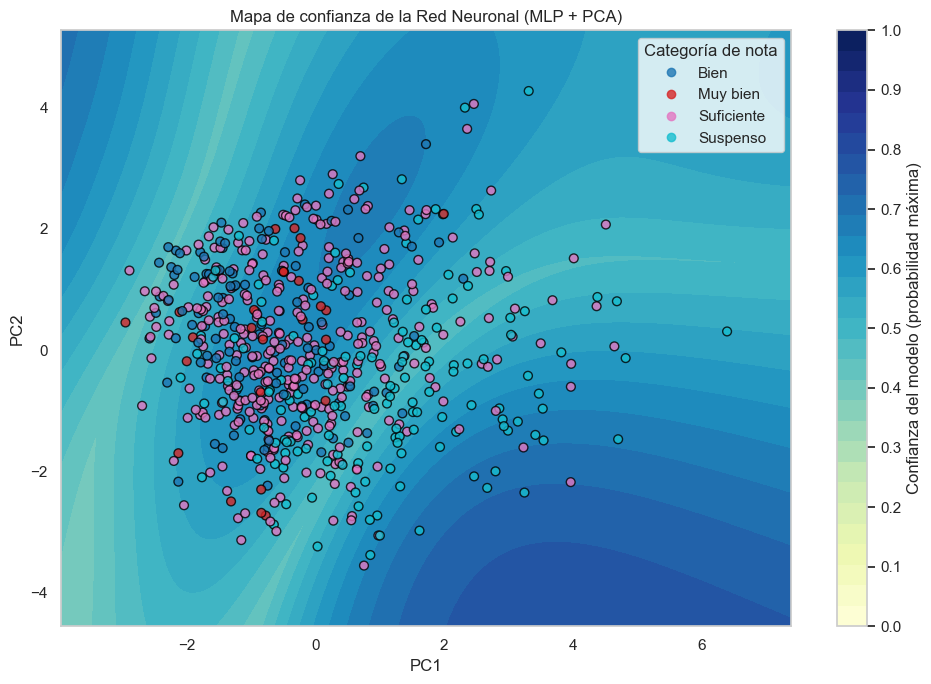

In [ ]:
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

probs = mlp_2d.predict_proba(grid_points)
confidence = probs.max(axis=1).reshape(xx.shape)

plt.figure(figsize=(10, 7))

contour = plt.contourf(
    xx, yy,
    confidence,
    levels=np.linspace(0, 1, 30),
    cmap="YlGnBu",
    vmin=0,
    vmax=1
)

scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=y_enc,
    cmap="tab10",
    edgecolor="black",
    s=40,
    alpha=0.8
)

cbar = plt.colorbar(contour, ticks=np.arange(0, 1.01, 0.1))
cbar.set_label("Confianza del modelo (probabilidad máxima)")

handles, _ = scatter.legend_elements()
plt.legend(
    handles,
    le.classes_,
    title="Categoría de nota",
    loc="upper right"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Mapa de confianza de la Red Neuronal (MLP + PCA)")

plt.tight_layout()
plt.show()


El mapa de confianza de la red neuronal en el espacio reducido por PCA muestra de forma clara cómo el modelo no solo clasifica a los estudiantes en distintas categorías de nota, sino que además asigna distintos niveles de seguridad a sus predicciones. Las zonas con tonalidades más oscuras (valores de confianza cercanos a 1) indican regiones del espacio PC1–PC2 donde la red neuronal realiza predicciones muy consistentes, lo que sugiere que en esos perfiles de estudiantes las características académicas y personales son suficientemente diferenciadas para asignar una categoría de rendimiento con alta fiabilidad. Por el contrario, las áreas con colores más claros corresponden a regiones de menor confianza, donde se observa una mayor superposición entre categorías como Suficiente y Bien, reflejando perfiles intermedios y más ambiguos. La concentración de estudiantes en zonas de confianza media-alta indica que el modelo ha aprendido patrones generales robustos, mientras que las transiciones suaves entre regiones confirman la naturaleza no lineal de la red neuronal frente a modelos más rígidos. En el contexto del trabajo, este gráfico aporta un valor añadido al evidenciar no solo qué predice el modelo, sino con qué grado de certeza, lo que permite identificar perfiles de estudiantes con mayor riesgo de clasificación errónea y refuerza la interpretación del rendimiento académico como un fenómeno continuo y multifactorial, más que como categorías estrictamente separadas.

# 7. Conclusiones finales

## 7.1 Análisis de métodos

En el análisis del rendimiento académico de los estudiantes se han aplicado distintas técnicas con objetivos complementarios: exploración de la estructura de los datos, identificación de perfiles de estudiantes y predicción del nivel de rendimiento, medido mediante **G_media** y su versión categorizada (**categoria_nota**). Cada método ha aportado una perspectiva diferente sobre los factores académicos, familiares y de comportamiento que influyen en las notas.

**PCA (Análisis de Componentes Principales):**  
El PCA se utilizó como herramienta exploratoria y de reducción de dimensionalidad. Permitió sintetizar la información de múltiples variables numéricas y ordinales en unos pocos componentes que explican una parte sustancial de la variabilidad del rendimiento académico. Los primeros componentes mostraron ejes claramente interpretables, relacionados con el riesgo académico (failures, absences, edad) frente al apoyo educativo y familiar (Medu, Fedu, studytime). Su principal aportación fue facilitar la visualización y la interpretación global de los datos, así como servir de apoyo para representar modelos más complejos, aunque no actúa como modelo predictivo en sí mismo.

**MDS (Escalamiento Multidimensional):**  
El MDS ofreció una visión complementaria al PCA al centrarse en preservar las distancias entre estudiantes en lugar de la varianza. Esta técnica permitió identificar agrupaciones y gradientes de rendimiento que no necesariamente responden a relaciones lineales entre variables. Las representaciones en 2D y 3D, coloreadas por **categoria_nota**, mostraron una separación progresiva entre estudiantes de bajo y alto rendimiento. Sin embargo, sus dimensiones carecen de una interpretación directa en términos de variables originales, por lo que su valor es principalmente exploratorio.

**K-Means:**  
El algoritmo K-Means se empleó para identificar perfiles de estudiantes con características similares. Los clústeres obtenidos reflejaron grupos coherentes en términos de hábitos de estudio, contexto familiar y resultados académicos, lo que permitió segmentar a los estudiantes en perfiles de riesgo y de mayor rendimiento. Aunque K-Means no es un método predictivo, resultó útil para comprender la heterogeneidad del alumnado y complementar los resultados obtenidos con las técnicas supervisadas.

**Árboles de Decisión:**  
Los árboles de decisión proporcionaron un modelo supervisado altamente interpretable para clasificar a los estudiantes según su **categoria_nota**. El modelo destacó variables clave como failures, studytime, absences y educación parental, estableciendo reglas claras y umbrales comprensibles. Su rendimiento predictivo fue razonable, pero inferior al de modelos más flexibles. Su principal fortaleza en el trabajo fue la interpretabilidad y la capacidad de explicar de forma transparente los factores que conducen a un determinado nivel de rendimiento académico.

**Redes Neuronales (MLP):**  
Las redes neuronales multicapa (MLP) fueron el método con mayor capacidad predictiva del estudio. Gracias a su flexibilidad, lograron capturar relaciones no lineales complejas entre las variables académicas, familiares y de comportamiento, obteniendo los mejores resultados de clasificación sobre **categoria_nota**. Las visualizaciones basadas en PCA, como las fronteras de decisión y el mapa de confianza, mostraron transiciones suaves entre clases y regiones de alta y baja seguridad en las predicciones. Aunque su interpretabilidad es menor que la de los árboles de decisión, su precisión y capacidad de generalización las convierten en la opción más adecuada cuando el objetivo principal es predecir el rendimiento académico.

**Conclusión general:**  
Si el criterio principal es la **capacidad predictiva**, las redes neuronales (MLP) constituyen el mejor enfoque para este conjunto de datos. Los árboles de decisión aportan un valor explicativo fundamental para entender los factores que influyen en las notas, mientras que PCA, MDS y K-Means desempeñan un papel clave en la exploración, visualización y segmentación de los estudiantes. En conjunto, la combinación de métodos permitió obtener una visión completa del problema, desde la interpretación de patrones hasta la predicción del rendimiento académico.


| Método | Tipo | Objetivo principal | Ventajas | Limitaciones | Aportación al trabajo |
|--------|------|-------------------|----------|--------------|----------------------|
| PCA | Reducción de dimensión | Explicar varianza | Alta interpretabilidad, biplot | Solo relaciones lineales | Identificación de ejes de riesgo vs. apoyo académico |
| MDS | Reducción de dimensión | Preservar distancias | Captura relaciones no lineales | Difícil interpretación | Confirmar estructura latente del rendimiento |
| K-means | Clustering | Agrupación | Simple, eficiente | Requiere k, sensible a escala | Validar perfiles de estudiantes |
| Árbol de decisión | Supervisado | Clasificación explicativa | Muy interpretable | Riesgo de overfitting | Explicar reglas que llevan a cada categoría de nota |
| Red neuronal (MLP) | Supervisado | Clasificación predictiva | Capta no linealidades complejas | Menor interpretabilidad | Mejor rendimiento predictivo y análisis de confianza |

## 8.2 Hipótesis

A partir de los análisis realizados a lo largo del trabajo, es posible contrastar las hipótesis planteadas apoyándonos únicamente en los resultados obtenidos:

**Hipótesis 1: El tiempo de estudio y el número de faltas serán los factores más influyentes en la categoría final.**
Esta hipótesis se confirma parcialmente. A lo largo del análisis, studytime muestra una relación positiva consistente con el rendimiento académico, apareciendo asociada a mejores valores de G_media tanto en el análisis correlacional como en los componentes principales del PCA. Por su parte, absences presenta una relación negativa moderada con el rendimiento, especialmente visible en el PCA y en los modelos supervisados, aunque su influencia es menos fuerte que la de otras variables académicas. En conjunto, ambas variables actúan como indicadores académicos relevantes, pero no son las únicas ni necesariamente las más dominantes en todos los métodos.

**Hipótesis 2: Las variables socioemocionales y familiares influyen de forma secundaria.**
Esta hipótesis se confirma. Variables como Medu y Fedu muestran una asociación clara y positiva con el rendimiento, especialmente en el PCA, donde se alinean con los valores altos de G_media. Sin embargo, su influencia es más moderada que la de los factores académicos directos. Las variables socioemocionales (goout, freetime, Dalc, Walc) aparecen principalmente en componentes secundarios o con menor importancia en los modelos supervisados, indicando un efecto complementario pero no dominante.

**Hipótesis 3: El clustering revelará grupos con perfiles característicos.**
Esta hipótesis se confirma. El uso de K-means, junto con las visualizaciones mediante PCA, permitió identificar agrupaciones de estudiantes con perfiles diferenciados, coherentes con niveles de rendimiento distintos. Se observaron grupos asociados a mayor riesgo académico , otros con mayor apoyo educativo y mejores resultados, y perfiles intermedios. Aunque las etiquetas no son perfectas, la estructura de grupos es consistente y significativa.

**Hipótesis 4: Las redes neuronales alcanzarán mayor precisión que los árboles de decisión, pero con menor interpretabilidad.**
Esta hipótesis se confirma claramente. Las redes neuronales (MLP) obtuvieron un rendimiento predictivo superior al de los árboles de decisión, capturando relaciones complejas entre las variables, como se refleja en la matriz de confusión y en el mapa de confianza. No obstante, los árboles de decisión ofrecieron reglas claras y fácilmente interpretables, lo que los hace especialmente valiosos desde una perspectiva educativa, a pesar de su menor precisión.

En conjunto, los resultados respaldan de forma sólida las hipótesis planteadas y muestran que el rendimiento académico es un fenómeno multifactorial, donde los factores académicos directos son clave, pero se ven modulados por el contexto familiar y conductual, y donde existe un equilibrio necesario entre precisión predictiva e interpretabilidad según el objetivo del análisis.

## 8.3 Conclusión

 El objetivo principal ha sido identificar qué factores académicos, personales, familiares y de comportamiento están asociados al rendimiento, así como evaluar qué metodologías analíticas resultan más adecuadas tanto para la comprensión del fenómeno como para su predicción.

En una primera fase exploratoria, el análisis descriptivo y relacional permitió obtener una visión clara de la estructura de los datos y de la naturaleza de las variables. La diferenciación entre variables numéricas, ordinales y categóricas resultó clave para aplicar correctamente las técnicas estadísticas y evitar interpretaciones erróneas. Este enfoque metodológico riguroso permitió confirmar que el rendimiento académico no depende de un único factor, sino de la combinación de múltiples dimensiones que interactúan entre sí.

Posteriormente, las técnicas de reducción de dimensionalidad aportaron una visión sintética del problema. El PCA permitió identificar ejes latentes claramente interpretables, especialmente un componente principal asociado al riesgo académico frente al apoyo educativo, donde variables como las ausencias, la edad o el número de fallos se oponen a factores como el nivel educativo de los padres y el tiempo de estudio. Esta interpretación reforzó la idea de que el rendimiento académico responde a un equilibrio entre hábitos académicos y contexto familiar. Por su parte, el MDS ofreció una perspectiva complementaria al centrarse en la similitud global entre estudiantes, revelando una estructura no aleatoria en la distribución del rendimiento y confirmando que existen patrones complejos que no siempre pueden capturarse mediante métodos lineales. Aunque menos interpretable, el MDS fue útil para validar la existencia de agrupaciones latentes en los datos.

En cuanto a los métodos no supervisados, el uso de K-means permitió identificar grupos de estudiantes con perfiles diferenciados, coherentes con distintos niveles de rendimiento académico. La baja proporción de outliers y la naturaleza mayoritariamente numérica y ordinal de las variables justificaron su elección frente a otros métodos de clustering. Estos clústeres aportaron una lectura cualitativa relevante del fenómeno, evidenciando la heterogeneidad del alumnado y reforzando la idea de que no existe un único perfil de estudiante, sino trayectorias académicas diversas.

En la fase supervisada, los árboles de decisión ofrecieron un modelo claramente interpretable, capaz de establecer reglas comprensibles sobre cómo distintas variables influyen en la categoría final de la nota. Aunque su capacidad predictiva es limitada frente a modelos más complejos, su valor explicativo es especialmente relevante en contextos educativos, donde la transparencia y la comprensión del modelo son fundamentales para la toma de decisiones. En contraste, las redes neuronales (MLP) demostraron una mayor capacidad predictiva, capturando relaciones no lineales complejas entre las variables y ofreciendo el mejor rendimiento global. Las visualizaciones avanzadas, como el mapa de confianza en el espacio PCA, permitieron además interpretar de forma visual la seguridad del modelo en sus predicciones, aportando un valor añadido al análisis.

Desde un punto de vista metodológico, el trabajo pone de manifiesto la importancia de combinar técnicas exploratorias, no supervisadas y supervisadas en lugar de depender de un único enfoque. Cada método ha cumplido una función específica: el PCA y el MDS han facilitado la comprensión global de los datos, el clustering ha permitido segmentar perfiles de estudiantes, y los modelos supervisados han evaluado la capacidad predictiva real de las variables analizadas. Esta combinación ha permitido no solo predecir el rendimiento académico, sino también entender por qué se producen determinados resultados.

En conclusión, el análisis realizado confirma que el rendimiento académico es un fenómeno multifactorial, donde los hábitos académicos directos (como las ausencias y el esfuerzo) juegan un papel central, mientras que los factores familiares y de comportamiento actúan como moduladores secundarios. Desde el punto de vista del objetivo del trabajo, las redes neuronales se presentan como el modelo más potente en términos predictivos, mientras que los árboles de decisión y las técnicas de reducción de dimensionalidad resultan esenciales para la interpretación y comprensión del fenómeno. El enfoque metodológico adoptado demuestra que, en el ámbito educativo, la mejor solución no es necesariamente un único modelo, sino una estrategia integrada que combine precisión, interpretabilidad y capacidad de análisis estructural.

# 9. Bibliografía

Centro de Estudios Cervantinos. (s. f.). Equivalencias de notas entre España y Portugal. Recuperado el 16 de diciembre de 2025, de
https://www.centroestudioscervantinos.es/equivalencias-notas-espana-portugal/

Gruher, B. (s. f.). Student Performance Prediction [Repositorio de GitHub]. GitHub. Recuperado el 16 de diciembre de 2025, de
https://github.com/bengruher/Student-Performance-Prediction

OpenAI. (2025). ChatGPT (modelo GPT-5.2) [Modelo de lenguaje de gran escala]. https://chat.openai.com/

## 9.1 Uso de la IA 

En este trabajo se ha utilizado inteligencia artificial generativa (IAGen), concretamente ChatGPT, como herramienta de apoyo metodológico y de redacción a lo largo del análisis del rendimiento académico de los estudiantes. La IA se empleó principalmente para mejorar la claridad expositiva y apoyar la interpretación de resultados obtenidos mediante técnicas estadísticas y de aprendizaje automático aplicadas a las notas de los estudiantes.

Asimismo, ChatGPT sirvió como asistencia en la generación, corrección y mejora del código en Python. El uso de la IA se mantuvo en todo momento como un apoyo técnico y conceptual, no como un sustituto del trabajo analítico del alumnado. La preparación de los datos, la ejecución del código, la interpretación crítica de los resultados, la validación de hipótesis y la adaptación de los métodos al objetivo del estudio fueron realizadas de forma manual. Los prompts empleados incluyeron solicitudes como “explica qué método es más adecuado para estos datos”, “ayúdame a interpretar este gráfico en el contexto del rendimiento académico”, o “reformula este análisis para un trabajo académico”, siempre integrando las respuestas de manera crítica y coherente con los contenidos vistos en clase.


In [5]:
!jupyter nbconvert --to html "Trabajo_individual_clasificacion.ipynb"

[NbConvertApp] Converting notebook Trabajo_individual_clasificacion.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 31 image(s).
[NbConvertApp] Writing 4090663 bytes to Trabajo_individual_clasificacion.html
